# EGB103 Assignment One - Structural Analysis for Bridge Design

Programming and software play a crucial role in aiding engineers in problem-solving tasks related to analyzing and designing structures like bridges using methods such as finite element analysis, free body diagrams, and truss analysis. These tools enable engineers to efficiently process complex mathematical calculations, simulate structural behaviors, and visualize results. Through programming, engineers can automate repetitive tasks, optimize algorithms, and implement sophisticated numerical methods, allowing them to explore various design scenarios rapidly. 

In this assignment, to help us learn Python in the context of an Authentic Engineering problem, we will use a Python Module called AnaStruct to model and analyse different truss bridge designs. The theory and mathematics behind the kind of analysis performed by AnaStruct will be covered in later units such as EGB121 Engineering Mechananics.

<div style="background-color: #ff5555; padding:10px; font-size:x-large; font-weight: bold">
    Part A - due Week 3 (Friday 15th March)
</div>

<div style="background-color: #00cc00; padding:10px; font-size:large; font-weight: bold">
Task 1: Edit this markdown cell, remove this comment and replace it with markdown that includes your name and briefly describes your previous programming experience if any.
</div>

In [1]:
# Always execute this code first before trying to execute any of the code cells below

import anastruct
import math

# Simple Demo of How to Use the AnaStruct Python Library

In this assignment you will use a Python Module called AnaStruct. The following simple example illustrates how to perform each of the key modelling and structural analysis tasks using Python code.

Run this code and visualize the results.

Browse through the code to learn how to perform each of the key modelling tasks using the AnaStruct library.

<div style="background-color: #00cc00; padding:10px; font-size:large; font-weight: bold">
Task 2: Run this code and visualize the results
</div>

structure:


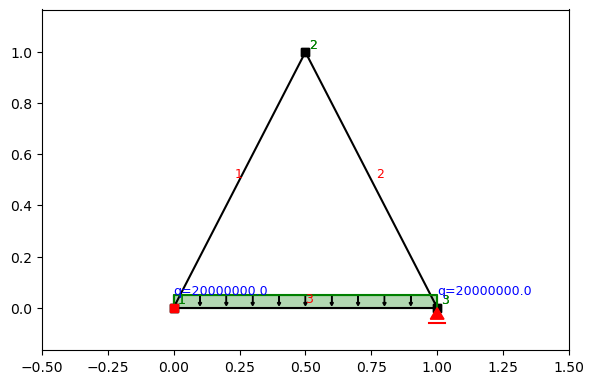

axial forces:


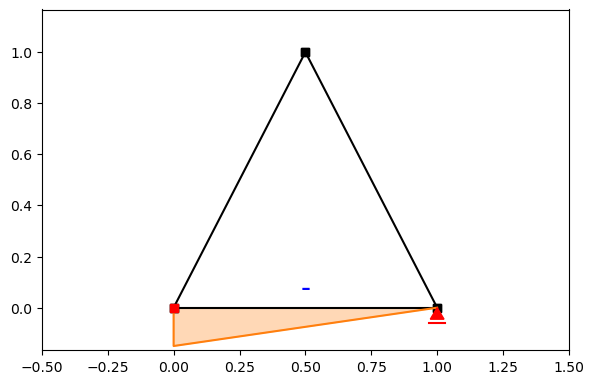

displacement:


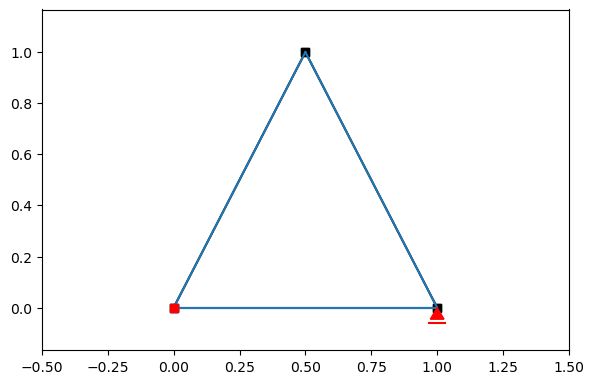

In [2]:
# We start by creating a new SystemElements object (from the anastruct module) and store it in a variable for later use.
bridge = anastruct.SystemElements()

# Next we will create a 2D model of the structure that we wish to analyse.
# A model is an abstraction of an object in the real-world, meaning that the model simplifies (and ignores) some details of the real world object that may make analysis more complex.
# The structure is made of up 2D elements (or edges) which are connected to one another at nodes or vertices.

# Next we create some variables to store the 2D coordinates for all of the vertices (represented as a tuple).
v1 = (0, 0)
v2 = (0.5, 1)
v3 = (1, 0)

# Next we create elements (i.e. edges) that connect two vertices.
# In this assignment we will be creating a specific type of structure referred to as a Truss.
# To create a truss element we call the add_truss_element method and invoke it on our SystemElements object created earlier.
# We pass to the add_truss_elements a list consisting of precisely 2 vertices that will be connected by this element.
# The add_truss_element method returns an element id which is an integer that can be used to later uniquely refer to that element.
left_element_id = bridge.add_truss_element([v1, v2])
right_element_id = bridge.add_truss_element([v2, v3])
bottom_element_id = bridge.add_truss_element([v1, v3])

# Internally, the SystemElements creates nodes for each of the vertices that we connect via elements. 
# These nodes have a unique node id which is an integer  that can  be used to later uniquely refer to that node.
# We can call the find_node_id method to retrieve the node id associated with a specific 2D coordinate (but only if it has already been connected via an element)
bottom_left_node_id = bridge.find_node_id(v1)
bottom_right_node_id = bridge.find_node_id(v3)

# To hold up the bridge we will add a fixed support under the bottom left corner of our bridge
bridge.add_support_fixed(bottom_left_node_id)
# On the right side of the bridge, rather than use a fixed support, we will instead use a roll support, which supports the bridge vertically but allows that vertex to move horizontally.
# Using this kind of roll support rather than a fixed support allows for expansion and contraction to occur.
bridge.add_support_roll(bottom_right_node_id)

# Next we apply a load vertically downward to the bottom element of our bridge, simulating the weight of the road surface and vehicles crossing the bridge.
weight = 20000000
bridge.q_load(q = -weight, element_id = bottom_element_id)

# We can call the show_structure method to visually inspect the bridge model that we have created.
# This is very useful to check  that we haven't made any obvious mistakes in building the model.
print("structure:")
bridge.show_structure(figsize=[6,4])

# This is where the magic happens!
# The solve method uses complex physics and mathematical techniques to analyse the effect of all of the forces and interations between connected elements.
# You will learn about these methods in later units such as EGB121 Engineering Mechananics.
# For now, we will leave these complex calculations to the AnaStruct library to solve for us.
bridge.solve()

# After analysing the effects of the forces, we can visualize the results in various ways, such as viewing the axial compression and tension forces acting on each element.
print("axial forces:")
bridge.show_axial_force(figsize=[6,4])

# We can also visualize how the elements may bend, stretch and sag as a result of severe loads.
# In this simple example, there is no visible displacement of any nodes.
print("displacement:")
bridge.show_displacement(figsize=[6,4])

# Compute Position of Top Left Vertex for each kind of Truss

In this assignment we will compare two different Bridge Truss designs:

**Warren Truss:**

![Warren Truss](https://images2.imgbox.com/01/c0/RhOz8eX4_o.png "Warren Truss") 

**Howe Truss:**

![Howe Truss](https://images2.imgbox.com/1a/1b/FmNXils9_o.png "Howe Truss") 

## Howe Truss

The first step is to compute the coordinates of each of the vertices.
The bottom leftmost vertice will always be placed at the origin, coordinate (0,0).

The coordinate of the top leftmost vertex will depend on the truss design.

For a Howe truss, we base this calculation on the fact that each segment of a Howe Truss is a perfect square with diagonals at 45 degrees:

![Howe Truss - Top Leftmost Vertex?](https://images2.imgbox.com/07/1c/H2blTetz_o.png "Howe Truss - Top Leftmost Vertex?") 

In [ ]:
# This function is provided to you - do not modify it in any way.
# Use it as example to help understand what is required for the warren_truss_top_left_vertex function that you must implement
# Parameters:
# - horizontal_segment_length is the horizontal length of each segment of the bridge
# Return value:
# - a tuple containing the x and y coordinates of the top left vertex
def howe_truss_top_left_vertex(horizontal_segment_length) :
    # since each segment is a perfect square, the x and y coordinates of the top left vertice will be the horizontal length of each segment.
    top_left_x = horizontal_segment_length
    top_left_y = horizontal_segment_length
    return (top_left_x, top_left_y) # return a tuple consisting of the x and y coordinates

### Tests ...

In [ ]:
import code_analyser

In [ ]:
result = howe_truss_top_left_vertex(1) 
code_analyser.assert_equal(result, (1, 1))

In [ ]:
result = howe_truss_top_left_vertex(1.5) 
code_analyser.assert_equal(result, (1.5, 1.5))

## Warren Truss

For a Warren Truss, we calculate the coordinates of the top leftmost vertices using trigonometry based on the fact that each of the segments is an equilateral triange (with equal length edges and equal internal angles of 60 degrees).

![Warren Truss - Top Leftmost Vertex?](https://images2.imgbox.com/39/a9/sEyA4q8L_o.png "Warren Truss - Top Leftmost Vertex?")


<div style="background-color: #00cc00; padding:10px; font-size:large; font-weight: bold">
Task 3: Implement the warren_truss_top_left_vertex function in the code cell below.
</div>

In [10]:
# Assuming that the bottom left vertex is located at the origin (0,0), compute the coordinates of the top leftmost vertex.
# We know that each segment of a Warren Truss is an equilateral triangle, so it will have equal length edges and equal internal angles of 60 degrees.
# We can therefore use trigonometry to calculate the x and y coodinates of the top left vertex based on this angle and the length of the base of the triangle. 
# Parameters:
# - horizontal_segment_length is the horizontal length of each segment of the bridge
# Return value:
# - a tuple containing the x and y coordinates of the top left vertex
def warren_truss_top_left_vertex(horizontal_segment_length) : # do not change this line in any way - the function name and parameters must remain exactly as specified here
 top_left_x = ???
 top_left_y = ???
 return (top_lef_x, top_left_y) # return a tuple consisting of the x and y coordinates

SyntaxError: invalid syntax (2747189347.py, line 9)

In [5]:
math.cos(math.radians(60))

0.5000000000000001

In [7]:
math.radians(60)

1.0471975511965976

In [8]:
math.pi/3


1.0471975511965976

### Tests ...

In [ ]:
result = warren_truss_top_left_vertex(1) 
code_analyser.assert_equal(result, (0.5, 0.8660254037844386), 'a1')

In [ ]:
result = warren_truss_top_left_vertex(1.5) 
code_analyser.assert_equal(result, (0.75, 1.299038105676658), 'a2')

In [ ]:
result = warren_truss_top_left_vertex(0.75) 
code_analyser.assert_equal(result, (0.375, 0.649519052838329), 'a3')

In [ ]:
result = warren_truss_top_left_vertex(3.14) 
code_analyser.assert_equal(result, (1.57, 2.719319767883137), 'a4')

<div style="background-color: #ff5555; padding:10px; font-size:x-large; font-weight: bold">
    Part B - due Week 6 (Friday 12th April)
</div>

# Evenly Space Horizontal Vertices

We note for both Warren and Howe trusses that the vertices are arranged into an upper (Red) and lower (Blue) row of equally spaced, horizontally arranged vertices.

![Howe Truss Rows](https://images2.imgbox.com/dd/a4/e6lqVbwR_o.png "Howe Truss Rows")   

![Warren Truss Rows](https://images2.imgbox.com/02/90/n1CvJukz_o.png "Warren Truss Rows") 

So, once we know the coordinates of the leftmost bottom coordinate (always 0,0) and we've calculated the coordinates for the leftmost top vertex, then it is a simple matter to compute the coordinates of all of the vertices in that row. So, we create the following helper function which we will later use to compute the positions of the top and bottom rows of vertices for both Warren and Howe trusses.

![Equally Spaced Horizontal Vertices](https://images2.imgbox.com/23/43/DORrv0Bb_o.png "Equally Spaced Horizontal Vertices")

<div style="background-color: #00cc00; padding:10px; font-size:large; font-weight: bold">
Task 4: Implement the evenly_spaced_horizontal_vertices function in the code cell below.
</div>

In [ ]:
# Parameters:
# - leftmost_vertex is a tuple containing the x and y coordinate  of the leftmost vertex.
# - horizontal_gap_between_vertices is a number representing the horizontal distance between vertices
# - number_of_vertices is the integer number of vertices that need to be returned.
# Return value:
# - a list of tuples containing the x,y coodinates for each vertex. All vertices should have the same y coordinate as the leftmost vertex.
def evenly_spaced_horizontal_vertices(leftmost_vertex, horizontal_gap_between_vertices, number_of_vertices) : # do not change this line in any way - the function name and parameters must remain exactly as specified here
    pass # ToDo: replace this line by your code

### Tests ...

In [ ]:
result = evenly_spaced_horizontal_vertices((1,1), 1, 5) 
code_analyser.assert_equal(result, [(1, 1), (2, 1), (3, 1), (4, 1), (5, 1)], 'b1')

In [ ]:
result = evenly_spaced_horizontal_vertices((0.6,1.5), 1, 5) 
code_analyser.assert_equal(result, [(0.6, 1.5), (1.6, 1.5), (2.6, 1.5), (3.6, 1.5), (4.6, 1.5)], 'b2')

In [ ]:
result = evenly_spaced_horizontal_vertices((1,1), 0.4, 6) 
code_analyser.assert_equal(result, [(1, 1), (1.4, 1), (1.8, 1), (2.2, 1), (2.6, 1), (3.0, 1)], 'b3')

In [ ]:
result = evenly_spaced_horizontal_vertices((0,0.5), 0.1, 8) 
code_analyser.assert_equal(result,  [(0, 0.5), (0.1, 0.5), (0.2, 0.5), (0.3, 0.5), (0.4, 0.5), (0.5, 0.5), (0.6, 0.5), (0.7, 0.5)], 'b4')

# Warren Truss

## Position Vertices

![Warren Truss Rows](https://images2.imgbox.com/9a/75/Ryl4ZDpH_o.png "Warren Truss Rows") 

The width of each segment will depend on the total horizontal distance that the bridge spans and the number of segments (on the lower level).

Start by computing the position of the top (red) vertices, then compute the position of the bottom (blue) vertices (using the functions we created above).

Then return a tuple containing both lists of vertices.


<div style="background-color: #00cc00; padding:10px; font-size:large; font-weight: bold">
Task 5: Implement the position_warren_truss_vertices function in the code cell below.
</div>

In [ ]:
# This function determines the x,y coordinates of each of the vertices in the top row and bottom row of a Warren Truss.
# Parameters:
# - horizontal_span_length is the total distance that the bridge spans (from the leftmost bottom vertice to the rightmost bottom vertex)
# - number_of_segments is the integer number of segments across the bottom of the bridge.
# Return values:
# - a tuple containing two lists of vertices for the top and bottom rows.
def position_warren_truss_vertices(horizontal_span_length, number_of_segments) : # do not change this line in any way - the function name and parameters must remain exactly as specified here
    pass # ToDo: replace this line by your code

### Tests ...

In [ ]:
result = position_warren_truss_vertices(1, 1) 
code_analyser.assert_equal(result, ([(0.5, 0.8660254037844386)], [(0, 0), (1.0, 0)]), 'c1')

In [ ]:
result = position_warren_truss_vertices(2.1, 1) 
code_analyser.assert_equal(result, ([(1.05, 1.818653347947321)], [(0, 0), (2.1, 0)]), 'c2')

In [ ]:
result = position_warren_truss_vertices(1, 2) 
code_analyser.assert_equal(result, ([(0.25000000000000006, 0.4330127018922193), (0.75, 0.4330127018922193)], [(0, 0), (0.5, 0), (1.0, 0)]), 'c3')

In [ ]:
result = position_warren_truss_vertices(5, 5) 
code_analyser.assert_equal(result, ([(0.5, 0.8660254037844386), (1.5, 0.8660254037844386), (2.5, 0.8660254037844386), (3.5, 0.8660254037844386), (4.5, 0.8660254037844386)], [(0, 0), (1.0, 0), (2.0, 0), (3.0, 0), (4.0, 0), (5.0, 0)]), 'c4')

In [ ]:
result = position_warren_truss_vertices(1.5, 6) 
code_analyser.assert_equal(result, ([(0.125, 0.21650635094610965), (0.375, 0.21650635094610965), (0.625, 0.21650635094610965), (0.875, 0.21650635094610965), (1.125, 0.21650635094610965), (1.375, 0.21650635094610965)], [(0, 0), (0.25, 0), (0.5, 0), (0.75, 0), (1.0, 0), (1.25, 0), (1.5, 0)]), 'c5')

In [ ]:
result = position_warren_truss_vertices(3.14, 8) 
code_analyser.assert_equal(result, ([(0.19625, 0.33991497098539214), (0.58875, 0.33991497098539214), (0.98125, 0.33991497098539214), (1.37375, 0.33991497098539214), (1.76625, 0.33991497098539214), (2.15875, 0.33991497098539214), (2.55125, 0.33991497098539214), (2.94375, 0.33991497098539214)], [(0, 0), (0.3925, 0), (0.785, 0), (1.1775, 0), (1.57, 0), (1.9625, 0), (2.355, 0), (2.7475, 0), (3.14, 0)]), 'c6')

## Warren Truss - Connect Vertices

![Connect Warren Vertices](https://images2.imgbox.com/6f/bd/dWdjKOh3_o.png "Connect Warren Vertices") 

The logic for connecting all these vertices according to the Warren Truss pattern can become overwhelming complicated.

So, as always, proceed step by step with each category of edges. First work out how to add each of the (orange) top edges. Once you've tested that and it works, go on to progressively add each of the (green) bottom edges, then the purple diagonally up edges and finally the pink diagonally down edges. Make sure you test after each step and get it working before proceeding. The tests below (for various sized bridges) will provide you with a visual depiction of the edges you have created, so you can easily spot any obvious mistakes.

Importantly, note how the top and bottom vertices are numbered in the diagram above. For example the pink edges are from node 0 of the top list to node 1 of the bottom list, from node 1 of the top list to node 2 of the bottom list and so on. Work out the pattern and use it to write a loop that indexes appropriately into the top and bottom vertex lists.

<div style="background-color: #00cc00; padding:10px; font-size:large; font-weight: bold">
Task 6: Implement the connect_warren_truss_vertices function in the code cell below.
</div>

In [ ]:
# This function adds truss elements to connect each of the top and bottom vertices according to the pattern of a Warren Truss.
# It also computes and returns a list of the element ids of the "green" elements across the bottom of the bridge.
# Parameters: 
# - bridge a SystemElements object from the AnaStruct module (to which we can add truss elements).
# - top_vertices a list of the x,y coordinates of the vertices in the top row (ordered from left to right)
# - bottom_vertices a list of the x,y coordinates of the vertices in the bottom row (ordered from left to right)
# Return values:
# - a list of the element ids of the "green" elements across the bottom of the bridge.
def connect_warren_truss_vertices(bridge, top_vertices, bottom_vertices) : # do not change this line in any way - the function name and parameters must remain exactly as specified here
    pass # ToDo: replace this line by your code

### Tests ...

In [ ]:
test_bridge21 = anastruct.SystemElements()
v0 = (0.5000000000000001, 0.8660254037844386)
test_top_vertices = [v0]
v1 = (0, 0)
v2 = (1.0, 0)
test_bottom_vertices = [v1, v2]
bottom_elements_result = connect_warren_truss_vertices(test_bridge21, test_top_vertices, test_bottom_vertices)
code_analyser.inspect_bridge(test_bridge21, bottom_elements_result, [v0, v1, v2],[(0, 1), (0, 2), (1, 2)], "d01")

In [ ]:
test_bridge22 = anastruct.SystemElements()
v0 = (0.25000000000000006, 0.4330127018922193)
v1 = (0.75, 0.4330127018922193)
test_top_vertices = [v0, v1]
v2 = (0, 0)
v3 = (0.5, 0)
v4 = (1.0, 0)
test_bottom_vertices = [v2, v3, v4]
bottom_elements_result = connect_warren_truss_vertices(test_bridge22, test_top_vertices, test_bottom_vertices)
code_analyser.inspect_bridge(test_bridge22, bottom_elements_result, [v0, v1, v2, v3, v4],[(0, 1), (0, 2), (0, 3), (1, 3), (1, 4), (2, 3), (3, 4)], "d02")

In [ ]:
test_bridge23 = anastruct.SystemElements()
v0 = (0.16666666666666669, 0.28867513459481287)
v1 = (0.5, 0.28867513459481287)
v2 = (0.8333333333333333, 0.28867513459481287)
test_top_vertices = [v0, v1, v2]
v3 = (0, 0)
v4 = (0.3333333333333333, 0)
v5 = (0.6666666666666666, 0)
v6 = (1.0, 0)
test_bottom_vertices = [v3, v4, v5, v6]
bottom_elements_result = connect_warren_truss_vertices(test_bridge23, test_top_vertices, test_bottom_vertices)
code_analyser.inspect_bridge(test_bridge23, bottom_elements_result, [v0, v1, v2, v3, v4, v5, v6],[(0, 1), (0, 3), (0, 4), (1, 2), (1, 4), (1, 5), (2, 5), (2, 6), (3, 4), (4, 5), (5, 6)], "d03")

In [ ]:
test_bridge24 = anastruct.SystemElements()
v0 = (0.12500000000000003, 0.21650635094610965)
v1 = (0.375, 0.21650635094610965)
v2 = (0.625, 0.21650635094610965)
v3 = (0.875, 0.21650635094610965)
test_top_vertices = [v0, v1, v2, v3]
v4 = (0, 0)
v5 = (0.25, 0)
v6 = (0.5, 0)
v7 = (0.75, 0)
v8 = (1.0, 0)
test_bottom_vertices = [v4, v5, v6, v7, v8]
bottom_elements_result = connect_warren_truss_vertices(test_bridge24, test_top_vertices, test_bottom_vertices)
code_analyser.inspect_bridge(test_bridge24, bottom_elements_result, [v0, v1, v2, v3, v4, v5, v6, v7, v8],[(0, 1), (0, 4), (0, 5), (1, 2), (1, 5), (1, 6), (2, 3), (2, 6), (2, 7), (3, 7), (3, 8), (4, 5), (5, 6), (6, 7), (7, 8)], "d04")

In [ ]:
test_bridge26 = anastruct.SystemElements()
v0 = (0.08333333333333334, 0.14433756729740643)
v1 = (0.25, 0.14433756729740643)
v2 = (0.41666666666666663, 0.14433756729740643)
v3 = (0.5833333333333333, 0.14433756729740643)
v4 = (0.7499999999999999, 0.14433756729740643)
v5 = (0.9166666666666665, 0.14433756729740643)
test_top_vertices = [v0, v1, v2, v3, v4, v5]
v6 = (0, 0)
v7 = (0.16666666666666666, 0)
v8 = (0.3333333333333333, 0)
v9 = (0.5, 0)
v10 = (0.6666666666666666, 0)
v11 = (0.8333333333333333, 0)
v12 = (0.9999999999999999, 0)
test_bottom_vertices = [v6, v7, v8, v9, v10, v11, v12]
bottom_elements_result = connect_warren_truss_vertices(test_bridge26, test_top_vertices, test_bottom_vertices)
code_analyser.inspect_bridge(test_bridge26, bottom_elements_result, [v0, v1, v2, v3, v4, v5, v6, v7, v8, v9, v10, v11, v12],[(0, 1), (0, 6), (0, 7), (1, 2), (1, 7), (1, 8), (2, 3), (2, 8), (2, 9), (3, 4), (3, 9), (3, 10), (4, 5), (4, 10), (4, 11), (5, 11), (5, 12), (6, 7), (7, 8), (8, 9), (9, 10), (10, 11), (11, 12)], "d05")

In [ ]:
test_bridge28 = anastruct.SystemElements()
v0 = (0.06250000000000001, 0.10825317547305482)
v1 = (0.1875, 0.10825317547305482)
v2 = (0.3125, 0.10825317547305482)
v3 = (0.4375, 0.10825317547305482)
v4 = (0.5625, 0.10825317547305482)
v5 = (0.6875, 0.10825317547305482)
v6 = (0.8125, 0.10825317547305482)
v7 = (0.9375, 0.10825317547305482)
test_top_vertices = [v0, v1, v2, v3, v4, v5, v6, v7]
v8 = (0, 0)
v9 = (0.125, 0)
v10 = (0.25, 0)
v11 = (0.375, 0)
v12 = (0.5, 0)
v13 = (0.625, 0)
v14 = (0.75, 0)
v15 = (0.875, 0)
v16 = (1.0, 0)
test_bottom_vertices = [v8, v9, v10, v11, v12, v13, v14, v15, v16]
bottom_elements_result = connect_warren_truss_vertices(test_bridge28, test_top_vertices, test_bottom_vertices)
code_analyser.inspect_bridge(test_bridge28, bottom_elements_result, [v0, v1, v2, v3, v4, v5, v6, v7, v8, v9, v10, v11, v12, v13, v14, v15, v16],[(0, 1), (0, 8), (0, 9), (1, 2), (1, 9), (1, 10), (2, 3), (2, 10), (2, 11), (3, 4), (3, 11), (3, 12), (4, 5), (4, 12), (4, 13), (5, 6), (5, 13), (5, 14), (6, 7), (6, 14), (6, 15), (7, 15), (7, 16), (8, 9), (9, 10), (10, 11), (11, 12), (12, 13), (13, 14), (14, 15), (15, 16)], "d06")

In [ ]:
test_bridge29 = anastruct.SystemElements()
v0 = (0.055555555555555566, 0.09622504486493762)
v1 = (0.16666666666666669, 0.09622504486493762)
v2 = (0.2777777777777778, 0.09622504486493762)
v3 = (0.3888888888888889, 0.09622504486493762)
v4 = (0.5, 0.09622504486493762)
v5 = (0.6111111111111112, 0.09622504486493762)
v6 = (0.7222222222222223, 0.09622504486493762)
v7 = (0.8333333333333335, 0.09622504486493762)
v8 = (0.9444444444444446, 0.09622504486493762)
test_top_vertices = [v0, v1, v2, v3, v4, v5, v6, v7, v8]
v9 = (0, 0)
v10 = (0.1111111111111111, 0)
v11 = (0.2222222222222222, 0)
v12 = (0.3333333333333333, 0)
v13 = (0.4444444444444444, 0)
v14 = (0.5555555555555556, 0)
v15 = (0.6666666666666667, 0)
v16 = (0.7777777777777779, 0)
v17 = (0.8888888888888891, 0)
v18 = (1.0000000000000002, 0)
test_bottom_vertices = [v9, v10, v11, v12, v13, v14, v15, v16, v17, v18]
bottom_elements_result = connect_warren_truss_vertices(test_bridge29, test_top_vertices, test_bottom_vertices)
code_analyser.inspect_bridge(test_bridge29, bottom_elements_result, [v0, v1, v2, v3, v4, v5, v6, v7, v8, v9, v10, v11, v12, v13, v14, v15, v16, v17, v18],[(0, 1), (0, 9), (0, 10), (1, 2), (1, 10), (1, 11), (2, 3), (2, 11), (2, 12), (3, 4), (3, 12), (3, 13), (4, 5), (4, 13), (4, 14), (5, 6), (5, 14), (5, 15), (6, 7), (6, 15), (6, 16), (7, 8), (7, 16), (7, 17), (8, 17), (8, 18), (9, 10), (10, 11), (11, 12), (12, 13), (13, 14), (14, 15), (15, 16), (16, 17), (17, 18)], "d07")

In [ ]:
test_bridge32 = anastruct.SystemElements()
v0 = (0.5000000000000001, 0.8660254037844386)
v1 = (1.5, 0.8660254037844386)
v2 = (2.5, 0.8660254037844386)
test_top_vertices = [v0, v1, v2]
v3 = (0, 0)
v4 = (1.0, 0)
v5 = (2.0, 0)
v6 = (3.0, 0)
test_bottom_vertices = [v3, v4, v5, v6]
bottom_elements_result = connect_warren_truss_vertices(test_bridge32, test_top_vertices, test_bottom_vertices)
code_analyser.inspect_bridge(test_bridge32, bottom_elements_result, [v0, v1, v2, v3, v4, v5, v6],[(0, 1), (0, 3), (0, 4), (1, 2), (1, 4), (1, 5), (2, 5), (2, 6), (3, 4), (4, 5), (5, 6)], "d08")

In [ ]:
test_bridge35 = anastruct.SystemElements()
v0 = (0.25000000000000006, 0.4330127018922193)
v1 = (0.75, 0.4330127018922193)
v2 = (1.25, 0.4330127018922193)
v3 = (1.75, 0.4330127018922193)
v4 = (2.25, 0.4330127018922193)
v5 = (2.75, 0.4330127018922193)
test_top_vertices = [v0, v1, v2, v3, v4, v5]
v6 = (0, 0)
v7 = (0.5, 0)
v8 = (1.0, 0)
v9 = (1.5, 0)
v10 = (2.0, 0)
v11 = (2.5, 0)
v12 = (3.0, 0)
test_bottom_vertices = [v6, v7, v8, v9, v10, v11, v12]
bottom_elements_result = connect_warren_truss_vertices(test_bridge35, test_top_vertices, test_bottom_vertices)
code_analyser.inspect_bridge(test_bridge35, bottom_elements_result, [v0, v1, v2, v3, v4, v5, v6, v7, v8, v9, v10, v11, v12],[(0, 1), (0, 6), (0, 7), (1, 2), (1, 7), (1, 8), (2, 3), (2, 8), (2, 9), (3, 4), (3, 9), (3, 10), (4, 5), (4, 10), (4, 11), (5, 11), (5, 12), (6, 7), (7, 8), (8, 9), (9, 10), (10, 11), (11, 12)], "d09")

In [ ]:
test_bridge38 = anastruct.SystemElements()
v0 = (0.16666666666666669, 0.28867513459481287)
v1 = (0.5, 0.28867513459481287)
v2 = (0.8333333333333333, 0.28867513459481287)
v3 = (1.1666666666666665, 0.28867513459481287)
v4 = (1.4999999999999998, 0.28867513459481287)
v5 = (1.833333333333333, 0.28867513459481287)
v6 = (2.1666666666666665, 0.28867513459481287)
v7 = (2.5, 0.28867513459481287)
v8 = (2.8333333333333335, 0.28867513459481287)
test_top_vertices = [v0, v1, v2, v3, v4, v5, v6, v7, v8]
v9 = (0, 0)
v10 = (0.3333333333333333, 0)
v11 = (0.6666666666666666, 0)
v12 = (1.0, 0)
v13 = (1.3333333333333333, 0)
v14 = (1.6666666666666665, 0)
v15 = (1.9999999999999998, 0)
v16 = (2.333333333333333, 0)
v17 = (2.6666666666666665, 0)
v18 = (3.0, 0)
test_bottom_vertices = [v9, v10, v11, v12, v13, v14, v15, v16, v17, v18]
bottom_elements_result = connect_warren_truss_vertices(test_bridge38, test_top_vertices, test_bottom_vertices)
code_analyser.inspect_bridge(test_bridge38, bottom_elements_result, [v0, v1, v2, v3, v4, v5, v6, v7, v8, v9, v10, v11, v12, v13, v14, v15, v16, v17, v18],[(0, 1), (0, 9), (0, 10), (1, 2), (1, 10), (1, 11), (2, 3), (2, 11), (2, 12), (3, 4), (3, 12), (3, 13), (4, 5), (4, 13), (4, 14), (5, 6), (5, 14), (5, 15), (6, 7), (6, 15), (6, 16), (7, 8), (7, 16), (7, 17), (8, 17), (8, 18), (9, 10), (10, 11), (11, 12), (12, 13), (13, 14), (14, 15), (15, 16), (16, 17), (17, 18)], "d10")

In [ ]:
test_bridge41 = anastruct.SystemElements()
v0 = (0.8333333333333336, 1.4433756729740643)
v1 = (2.5000000000000004, 1.4433756729740643)
v2 = (4.166666666666667, 1.4433756729740643)
test_top_vertices = [v0, v1, v2]
v3 = (0, 0)
v4 = (1.6666666666666667, 0)
v5 = (3.3333333333333335, 0)
v6 = (5.0, 0)
test_bottom_vertices = [v3, v4, v5, v6]
bottom_elements_result = connect_warren_truss_vertices(test_bridge41, test_top_vertices, test_bottom_vertices)
code_analyser.inspect_bridge(test_bridge41, bottom_elements_result, [v0, v1, v2, v3, v4, v5, v6],[(0, 1), (0, 3), (0, 4), (1, 2), (1, 4), (1, 5), (2, 5), (2, 6), (3, 4), (4, 5), (5, 6)], "d11")

In [ ]:
test_bridge44 = anastruct.SystemElements()
v0 = (0.4166666666666668, 0.7216878364870322)
v1 = (1.2500000000000002, 0.7216878364870322)
v2 = (2.0833333333333335, 0.7216878364870322)
v3 = (2.916666666666667, 0.7216878364870322)
v4 = (3.7500000000000004, 0.7216878364870322)
v5 = (4.583333333333334, 0.7216878364870322)
test_top_vertices = [v0, v1, v2, v3, v4, v5]
v6 = (0, 0)
v7 = (0.8333333333333334, 0)
v8 = (1.6666666666666667, 0)
v9 = (2.5, 0)
v10 = (3.3333333333333335, 0)
v11 = (4.166666666666667, 0)
v12 = (5.0, 0)
test_bottom_vertices = [v6, v7, v8, v9, v10, v11, v12]
bottom_elements_result = connect_warren_truss_vertices(test_bridge44, test_top_vertices, test_bottom_vertices)
code_analyser.inspect_bridge(test_bridge44, bottom_elements_result, [v0, v1, v2, v3, v4, v5, v6, v7, v8, v9, v10, v11, v12],[(0, 1), (0, 6), (0, 7), (1, 2), (1, 7), (1, 8), (2, 3), (2, 8), (2, 9), (3, 4), (3, 9), (3, 10), (4, 5), (4, 10), (4, 11), (5, 11), (5, 12), (6, 7), (7, 8), (8, 9), (9, 10), (10, 11), (11, 12)], "d12")

In [ ]:
test_bridge47 = anastruct.SystemElements()
v0 = (0.27777777777777785, 0.4811252243246881)
v1 = (0.8333333333333335, 0.4811252243246881)
v2 = (1.388888888888889, 0.4811252243246881)
v3 = (1.9444444444444446, 0.4811252243246881)
v4 = (2.5, 0.4811252243246881)
v5 = (3.0555555555555554, 0.4811252243246881)
v6 = (3.6111111111111107, 0.4811252243246881)
v7 = (4.166666666666666, 0.4811252243246881)
v8 = (4.722222222222221, 0.4811252243246881)
test_top_vertices = [v0, v1, v2, v3, v4, v5, v6, v7, v8]
v9 = (0, 0)
v10 = (0.5555555555555556, 0)
v11 = (1.1111111111111112, 0)
v12 = (1.6666666666666667, 0)
v13 = (2.2222222222222223, 0)
v14 = (2.7777777777777777, 0)
v15 = (3.333333333333333, 0)
v16 = (3.8888888888888884, 0)
v17 = (4.444444444444444, 0)
v18 = (4.999999999999999, 0)
test_bottom_vertices = [v9, v10, v11, v12, v13, v14, v15, v16, v17, v18]
bottom_elements_result = connect_warren_truss_vertices(test_bridge47, test_top_vertices, test_bottom_vertices)
code_analyser.inspect_bridge(test_bridge47, bottom_elements_result, [v0, v1, v2, v3, v4, v5, v6, v7, v8, v9, v10, v11, v12, v13, v14, v15, v16, v17, v18],[(0, 1), (0, 9), (0, 10), (1, 2), (1, 10), (1, 11), (2, 3), (2, 11), (2, 12), (3, 4), (3, 12), (3, 13), (4, 5), (4, 13), (4, 14), (5, 6), (5, 14), (5, 15), (6, 7), (6, 15), (6, 16), (7, 8), (7, 16), (7, 17), (8, 17), (8, 18), (9, 10), (10, 11), (11, 12), (12, 13), (13, 14), (14, 15), (15, 16), (16, 17), (17, 18)], "d13")

In [ ]:
test_bridge50 = anastruct.SystemElements()
v0 = (1.166666666666667, 2.0207259421636903)
v1 = (3.5000000000000004, 2.0207259421636903)
v2 = (5.833333333333334, 2.0207259421636903)
test_top_vertices = [v0, v1, v2]
v3 = (0, 0)
v4 = (2.3333333333333335, 0)
v5 = (4.666666666666667, 0)
v6 = (7.0, 0)
test_bottom_vertices = [v3, v4, v5, v6]
bottom_elements_result = connect_warren_truss_vertices(test_bridge50, test_top_vertices, test_bottom_vertices)
code_analyser.inspect_bridge(test_bridge50, bottom_elements_result, [v0, v1, v2, v3, v4, v5, v6],[(0, 1), (0, 3), (0, 4), (1, 2), (1, 4), (1, 5), (2, 5), (2, 6), (3, 4), (4, 5), (5, 6)], "d14")

In [ ]:
test_bridge53 = anastruct.SystemElements()
v0 = (0.5833333333333335, 1.0103629710818451)
v1 = (1.7500000000000002, 1.0103629710818451)
v2 = (2.916666666666667, 1.0103629710818451)
v3 = (4.083333333333334, 1.0103629710818451)
v4 = (5.250000000000001, 1.0103629710818451)
v5 = (6.416666666666668, 1.0103629710818451)
test_top_vertices = [v0, v1, v2, v3, v4, v5]
v6 = (0, 0)
v7 = (1.1666666666666667, 0)
v8 = (2.3333333333333335, 0)
v9 = (3.5, 0)
v10 = (4.666666666666667, 0)
v11 = (5.833333333333334, 0)
v12 = (7.000000000000001, 0)
test_bottom_vertices = [v6, v7, v8, v9, v10, v11, v12]
bottom_elements_result = connect_warren_truss_vertices(test_bridge53, test_top_vertices, test_bottom_vertices)
code_analyser.inspect_bridge(test_bridge53, bottom_elements_result, [v0, v1, v2, v3, v4, v5, v6, v7, v8, v9, v10, v11, v12],[(0, 1), (0, 6), (0, 7), (1, 2), (1, 7), (1, 8), (2, 3), (2, 8), (2, 9), (3, 4), (3, 9), (3, 10), (4, 5), (4, 10), (4, 11), (5, 11), (5, 12), (6, 7), (7, 8), (8, 9), (9, 10), (10, 11), (11, 12)], "d15")

In [ ]:
test_bridge56 = anastruct.SystemElements()
v0 = (0.388888888888889, 0.6735753140545634)
v1 = (1.1666666666666667, 0.6735753140545634)
v2 = (1.9444444444444446, 0.6735753140545634)
v3 = (2.7222222222222223, 0.6735753140545634)
v4 = (3.5, 0.6735753140545634)
v5 = (4.277777777777778, 0.6735753140545634)
v6 = (5.055555555555555, 0.6735753140545634)
v7 = (5.833333333333333, 0.6735753140545634)
v8 = (6.611111111111111, 0.6735753140545634)
test_top_vertices = [v0, v1, v2, v3, v4, v5, v6, v7, v8]
v9 = (0, 0)
v10 = (0.7777777777777778, 0)
v11 = (1.5555555555555556, 0)
v12 = (2.3333333333333335, 0)
v13 = (3.111111111111111, 0)
v14 = (3.888888888888889, 0)
v15 = (4.666666666666667, 0)
v16 = (5.444444444444445, 0)
v17 = (6.222222222222222, 0)
v18 = (7.0, 0)
test_bottom_vertices = [v9, v10, v11, v12, v13, v14, v15, v16, v17, v18]
bottom_elements_result = connect_warren_truss_vertices(test_bridge56, test_top_vertices, test_bottom_vertices)
code_analyser.inspect_bridge(test_bridge56, bottom_elements_result, [v0, v1, v2, v3, v4, v5, v6, v7, v8, v9, v10, v11, v12, v13, v14, v15, v16, v17, v18],[(0, 1), (0, 9), (0, 10), (1, 2), (1, 10), (1, 11), (2, 3), (2, 11), (2, 12), (3, 4), (3, 12), (3, 13), (4, 5), (4, 13), (4, 14), (5, 6), (5, 14), (5, 15), (6, 7), (6, 15), (6, 16), (7, 8), (7, 16), (7, 17), (8, 17), (8, 18), (9, 10), (10, 11), (11, 12), (12, 13), (13, 14), (14, 15), (15, 16), (16, 17), (17, 18)], "d16")

In [ ]:
test_bridge57 = anastruct.SystemElements()
v0 = (4.500000000000001, 7.794228634059947)
test_top_vertices = [v0]
v1 = (0, 0)
v2 = (9.0, 0)
test_bottom_vertices = [v1, v2]
bottom_elements_result = connect_warren_truss_vertices(test_bridge57, test_top_vertices, test_bottom_vertices)
code_analyser.inspect_bridge(test_bridge57, bottom_elements_result, [v0, v1, v2],[(0, 1), (0, 2), (1, 2)], "d17")

In [ ]:
test_bridge60 = anastruct.SystemElements()
v0 = (1.1250000000000002, 1.9485571585149868)
v1 = (3.375, 1.9485571585149868)
v2 = (5.625, 1.9485571585149868)
v3 = (7.875, 1.9485571585149868)
test_top_vertices = [v0, v1, v2, v3]
v4 = (0, 0)
v5 = (2.25, 0)
v6 = (4.5, 0)
v7 = (6.75, 0)
v8 = (9.0, 0)
test_bottom_vertices = [v4, v5, v6, v7, v8]
bottom_elements_result = connect_warren_truss_vertices(test_bridge60, test_top_vertices, test_bottom_vertices)
code_analyser.inspect_bridge(test_bridge60, bottom_elements_result, [v0, v1, v2, v3, v4, v5, v6, v7, v8],[(0, 1), (0, 4), (0, 5), (1, 2), (1, 5), (1, 6), (2, 3), (2, 6), (2, 7), (3, 7), (3, 8), (4, 5), (5, 6), (6, 7), (7, 8)], "d18")

In [ ]:
test_bridge63 = anastruct.SystemElements()
v0 = (0.642857142857143, 1.1134612334371354)
v1 = (1.9285714285714288, 1.1134612334371354)
v2 = (3.2142857142857144, 1.1134612334371354)
v3 = (4.5, 1.1134612334371354)
v4 = (5.785714285714286, 1.1134612334371354)
v5 = (7.071428571428571, 1.1134612334371354)
v6 = (8.357142857142858, 1.1134612334371354)
test_top_vertices = [v0, v1, v2, v3, v4, v5, v6]
v7 = (0, 0)
v8 = (1.2857142857142858, 0)
v9 = (2.5714285714285716, 0)
v10 = (3.8571428571428577, 0)
v11 = (5.142857142857143, 0)
v12 = (6.428571428571429, 0)
v13 = (7.714285714285714, 0)
v14 = (9.0, 0)
test_bottom_vertices = [v7, v8, v9, v10, v11, v12, v13, v14]
bottom_elements_result = connect_warren_truss_vertices(test_bridge63, test_top_vertices, test_bottom_vertices)
code_analyser.inspect_bridge(test_bridge63, bottom_elements_result, [v0, v1, v2, v3, v4, v5, v6, v7, v8, v9, v10, v11, v12, v13, v14],[(0, 1), (0, 7), (0, 8), (1, 2), (1, 8), (1, 9), (2, 3), (2, 9), (2, 10), (3, 4), (3, 10), (3, 11), (4, 5), (4, 11), (4, 12), (5, 6), (5, 12), (5, 13), (6, 13), (6, 14), (7, 8), (8, 9), (9, 10), (10, 11), (11, 12), (12, 13), (13, 14)], "d19")

In [ ]:
test_bridge67 = anastruct.SystemElements()
v0 = (0.5000000000000001, 0.8660254037844386)
v1 = (1.5, 0.8660254037844386)
v2 = (2.5, 0.8660254037844386)
v3 = (3.5, 0.8660254037844386)
v4 = (4.5, 0.8660254037844386)
v5 = (5.5, 0.8660254037844386)
v6 = (6.5, 0.8660254037844386)
v7 = (7.5, 0.8660254037844386)
v8 = (8.5, 0.8660254037844386)
v9 = (9.5, 0.8660254037844386)
v10 = (10.5, 0.8660254037844386)
v11 = (11.5, 0.8660254037844386)
v12 = (12.5, 0.8660254037844386)
v13 = (13.5, 0.8660254037844386)
v14 = (14.5, 0.8660254037844386)
v15 = (15.5, 0.8660254037844386)
v16 = (16.5, 0.8660254037844386)
v17 = (17.5, 0.8660254037844386)
v18 = (18.5, 0.8660254037844386)
v19 = (19.5, 0.8660254037844386)
v20 = (20.5, 0.8660254037844386)
v21 = (21.5, 0.8660254037844386)
v22 = (22.5, 0.8660254037844386)
v23 = (23.5, 0.8660254037844386)
v24 = (24.5, 0.8660254037844386)
v25 = (25.5, 0.8660254037844386)
v26 = (26.5, 0.8660254037844386)
v27 = (27.5, 0.8660254037844386)
v28 = (28.5, 0.8660254037844386)
v29 = (29.5, 0.8660254037844386)
v30 = (30.5, 0.8660254037844386)
v31 = (31.5, 0.8660254037844386)
v32 = (32.5, 0.8660254037844386)
v33 = (33.5, 0.8660254037844386)
v34 = (34.5, 0.8660254037844386)
v35 = (35.5, 0.8660254037844386)
v36 = (36.5, 0.8660254037844386)
v37 = (37.5, 0.8660254037844386)
v38 = (38.5, 0.8660254037844386)
v39 = (39.5, 0.8660254037844386)
v40 = (40.5, 0.8660254037844386)
v41 = (41.5, 0.8660254037844386)
v42 = (42.5, 0.8660254037844386)
v43 = (43.5, 0.8660254037844386)
v44 = (44.5, 0.8660254037844386)
v45 = (45.5, 0.8660254037844386)
v46 = (46.5, 0.8660254037844386)
v47 = (47.5, 0.8660254037844386)
v48 = (48.5, 0.8660254037844386)
v49 = (49.5, 0.8660254037844386)
test_top_vertices = [v0, v1, v2, v3, v4, v5, v6, v7, v8, v9, v10, v11, v12, v13, v14, v15, v16, v17, v18, v19, v20, v21, v22, v23, v24, v25, v26, v27, v28, v29, v30, v31, v32, v33, v34, v35, v36, v37, v38, v39, v40, v41, v42, v43, v44, v45, v46, v47, v48, v49]
v50 = (0, 0)
v51 = (1.0, 0)
v52 = (2.0, 0)
v53 = (3.0, 0)
v54 = (4.0, 0)
v55 = (5.0, 0)
v56 = (6.0, 0)
v57 = (7.0, 0)
v58 = (8.0, 0)
v59 = (9.0, 0)
v60 = (10.0, 0)
v61 = (11.0, 0)
v62 = (12.0, 0)
v63 = (13.0, 0)
v64 = (14.0, 0)
v65 = (15.0, 0)
v66 = (16.0, 0)
v67 = (17.0, 0)
v68 = (18.0, 0)
v69 = (19.0, 0)
v70 = (20.0, 0)
v71 = (21.0, 0)
v72 = (22.0, 0)
v73 = (23.0, 0)
v74 = (24.0, 0)
v75 = (25.0, 0)
v76 = (26.0, 0)
v77 = (27.0, 0)
v78 = (28.0, 0)
v79 = (29.0, 0)
v80 = (30.0, 0)
v81 = (31.0, 0)
v82 = (32.0, 0)
v83 = (33.0, 0)
v84 = (34.0, 0)
v85 = (35.0, 0)
v86 = (36.0, 0)
v87 = (37.0, 0)
v88 = (38.0, 0)
v89 = (39.0, 0)
v90 = (40.0, 0)
v91 = (41.0, 0)
v92 = (42.0, 0)
v93 = (43.0, 0)
v94 = (44.0, 0)
v95 = (45.0, 0)
v96 = (46.0, 0)
v97 = (47.0, 0)
v98 = (48.0, 0)
v99 = (49.0, 0)
v100 = (50.0, 0)
test_bottom_vertices = [v50, v51, v52, v53, v54, v55, v56, v57, v58, v59, v60, v61, v62, v63, v64, v65, v66, v67, v68, v69, v70, v71, v72, v73, v74, v75, v76, v77, v78, v79, v80, v81, v82, v83, v84, v85, v86, v87, v88, v89, v90, v91, v92, v93, v94, v95, v96, v97, v98, v99, v100]
bottom_elements_result = connect_warren_truss_vertices(test_bridge67, test_top_vertices, test_bottom_vertices)
code_analyser.inspect_bridge(test_bridge67, bottom_elements_result, [v0, v1, v2, v3, v4, v5, v6, v7, v8, v9, v10, v11, v12, v13, v14, v15, v16, v17, v18, v19, v20, v21, v22, v23, v24, v25, v26, v27, v28, v29, v30, v31, v32, v33, v34, v35, v36, v37, v38, v39, v40, v41, v42, v43, v44, v45, v46, v47, v48, v49, v50, v51, v52, v53, v54, v55, v56, v57, v58, v59, v60, v61, v62, v63, v64, v65, v66, v67, v68, v69, v70, v71, v72, v73, v74, v75, v76, v77, v78, v79, v80, v81, v82, v83, v84, v85, v86, v87, v88, v89, v90, v91, v92, v93, v94, v95, v96, v97, v98, v99, v100],[(0, 1), (0, 50), (0, 51), (1, 2), (1, 51), (1, 52), (2, 3), (2, 52), (2, 53), (3, 4), (3, 53), (3, 54), (4, 5), (4, 54), (4, 55), (5, 6), (5, 55), (5, 56), (6, 7), (6, 56), (6, 57), (7, 8), (7, 57), (7, 58), (8, 9), (8, 58), (8, 59), (9, 10), (9, 59), (9, 60), (10, 11), (10, 60), (10, 61), (11, 12), (11, 61), (11, 62), (12, 13), (12, 62), (12, 63), (13, 14), (13, 63), (13, 64), (14, 15), (14, 64), (14, 65), (15, 16), (15, 65), (15, 66), (16, 17), (16, 66), (16, 67), (17, 18), (17, 67), (17, 68), (18, 19), (18, 68), (18, 69), (19, 20), (19, 69), (19, 70), (20, 21), (20, 70), (20, 71), (21, 22), (21, 71), (21, 72), (22, 23), (22, 72), (22, 73), (23, 24), (23, 73), (23, 74), (24, 25), (24, 74), (24, 75), (25, 26), (25, 75), (25, 76), (26, 27), (26, 76), (26, 77), (27, 28), (27, 77), (27, 78), (28, 29), (28, 78), (28, 79), (29, 30), (29, 79), (29, 80), (30, 31), (30, 80), (30, 81), (31, 32), (31, 81), (31, 82), (32, 33), (32, 82), (32, 83), (33, 34), (33, 83), (33, 84), (34, 35), (34, 84), (34, 85), (35, 36), (35, 85), (35, 86), (36, 37), (36, 86), (36, 87), (37, 38), (37, 87), (37, 88), (38, 39), (38, 88), (38, 89), (39, 40), (39, 89), (39, 90), (40, 41), (40, 90), (40, 91), (41, 42), (41, 91), (41, 92), (42, 43), (42, 92), (42, 93), (43, 44), (43, 93), (43, 94), (44, 45), (44, 94), (44, 95), (45, 46), (45, 95), (45, 96), (46, 47), (46, 96), (46, 97), (47, 48), (47, 97), (47, 98), (48, 49), (48, 98), (48, 99), (49, 99), (49, 100), (50, 51), (51, 52), (52, 53), (53, 54), (54, 55), (55, 56), (56, 57), (57, 58), (58, 59), (59, 60), (60, 61), (61, 62), (62, 63), (63, 64), (64, 65), (65, 66), (66, 67), (67, 68), (68, 69), (69, 70), (70, 71), (71, 72), (72, 73), (73, 74), (74, 75), (75, 76), (76, 77), (77, 78), (78, 79), (79, 80), (80, 81), (81, 82), (82, 83), (83, 84), (84, 85), (85, 86), (86, 87), (87, 88), (88, 89), (89, 90), (90, 91), (91, 92), (92, 93), (93, 94), (94, 95), (95, 96), (96, 97), (97, 98), (98, 99), (99, 100)], "d20")

## Build Warren Truss

In [ ]:
# This function has been provided for you - do not modify it in any way
# This function positions vertices and then adds truss elements to connect vertices according to a Warren Truss pattern.
# Parameters:
# - bridge a SystemElements object from the AnaStruct module (to which we can add truss elements).
# - horizontal_span_length is the total distance that the bridge spans (from the leftmost bottom vertice to the rightmost bottom vertex)
# - number_of_segments is the integer number of segments across the bottom of the bridge.
# Return values:
# - a tuple consisting of the list of vertices on the bottom and a list of element ids for the bottom elements.
def build_warren_truss(bridge, horizontal_span_length, number_of_segments) : 
    # find the position of all vertices (top and bottom rows)
    top_vertices, bottom_vertices = position_warren_truss_vertices(horizontal_span_length, number_of_segments)
    
    # connect vertices based on warren truss structure
    bottom_elements = connect_warren_truss_vertices(bridge, top_vertices, bottom_vertices)       
    
    # return separate lists for top and bottom rows
    return bottom_vertices, bottom_elements

### Tests ...

In [ ]:
test_bridge100 = anastruct.SystemElements()
build_warren_truss(test_bridge100, 2, 2)


# Howe Truss

## Position Vertices

![Howe Truss Rows](https://images2.imgbox.com/dd/a4/e6lqVbwR_o.png "Howe Truss Rows")   

Positioning the vertices for a Howe truss is largely the same as for a Warren Truss, the only real difference is computing the location of the top leftmost vertex (using the function created earlier).

<div style="background-color: #00cc00; padding:10px; font-size:large; font-weight: bold">
Task 7: Implement the position_howe_truss_vertices function in the code cell below.
</div>

In [ ]:
# This function determines the x,y coordinates of each of the vertices in the top row and bottom row of a Howe Truss.
# Parameters:
# - horizontal_span_length is the total distance that the bridge spans (from the leftmost bottom vertice to  the rightmost bottom vertex)
# - number_of_segments is the integer number of segments across the bottom of the bridge.
# Return values:
# - a tuple containing two lists of vertices for the top and bottom rows.
def position_howe_truss_vertices(horizontal_span_length, number_of_segments) : # do not change this line in any way - the function name and parameters must remain exactly as specified here
    pass # ToDo: replace this line by your code

### Tests ...

In [ ]:
result = position_howe_truss_vertices(1, 1) 
code_analyser.assert_equal(result, ([], [(0, 0), (1.0, 0)]), 'e1')

In [ ]:
result = position_howe_truss_vertices(2.1, 1) 
code_analyser.assert_equal(result, ([], [(0, 0), (2.1, 0)]), 'e2')

In [ ]:
result = position_howe_truss_vertices(1, 2) 
code_analyser.assert_equal(result, ([(0.5, 0.5)], [(0, 0), (0.5, 0), (1.0, 0)]), 'e3')

In [ ]:
result = position_howe_truss_vertices(5, 5) 
code_analyser.assert_equal(result, ([(1.0, 1.0), (2.0, 1.0), (3.0, 1.0), (4.0, 1.0)], [(0, 0), (1.0, 0), (2.0, 0), (3.0, 0), (4.0, 0), (5.0, 0)]), 'e4')

In [ ]:
result = position_howe_truss_vertices(1.5, 6) 
code_analyser.assert_equal(result, ([(0.25, 0.25), (0.5, 0.25), (0.75, 0.25), (1.0, 0.25), (1.25, 0.25)], [(0, 0), (0.25, 0), (0.5, 0), (0.75, 0), (1.0, 0), (1.25, 0), (1.5, 0)]), 'e5')

In [ ]:
result = position_howe_truss_vertices(3.14, 8) 
code_analyser.assert_equal(result, ([(0.3925, 0.3925), (0.785, 0.3925), (1.1775, 0.3925), (1.57, 0.3925), (1.9625, 0.3925), (2.355, 0.3925), (2.7475, 0.3925)], [(0, 0), (0.3925, 0), (0.785, 0), (1.1775, 0), (1.57, 0), (1.9625, 0), (2.355, 0), (2.7475, 0), (3.14, 0)]), 'e6')

## Howe Truss - Connecting Vertices

![Connect Howe Vertices](https://images2.imgbox.com/6d/9f/hAlR1Ndy_o.png "Connect Howe Vertices")   

As when connecting the Warren Truss Vertices, we should proceed step by step to add each of the five categories of edges: the top orange edges, the bottom green edges, the black vertical edges, the purple diagonally up edges (on the left side of the bridge) and the pink diagonally down edges (on the right side of the bridge).

In the example above there are 6 segments, so there will be 3 purple edges and 3 pink edges. However, your code should work for any (even) number of segments. 

![Connect Howe Vertices Longer](https://images2.imgbox.com/51/da/dCLdISZK_o.png "Connect Howe Vertices Longer")   

The switch from diagonally up to diagonally down always happens at the midpoint of the bridge. A Howe Truss bridge must therefore always consist of an even number of segments.

<div style="background-color: #00cc00; padding:10px; font-size:large; font-weight: bold">
Task 8: Implement the connect_howe_truss_vertices function in the code cell below.
</div>

In [ ]:
# This function adds truss elements to connect each of the top and bottom vertices according to the pattern of a Howe Truss.
# It also computes and returns a list of the element ids of the "green" elements across the bottom of the bridge.
# Parameters:
# - bridge a SystemElements object from the AnaStruct module (to which we can add truss elements).
# - top_vertices a list of the x,y coordinates of the vertices in the top row (ordered from left to right)
# - bottom_vertices a list of the x,y coordinates of the vertices in the bottom row (ordered from left to right)
# Return values:
# - a list of the element ids of the "green" elements across the bottom of the bridge.
def connect_howe_truss_vertices(bridge, top_vertices, bottom_vertices) : # do not change this line in any way - the function name and parameters must remain exactly as specified here
    pass # ToDo: replace this line by your code

### Tests ...


In [ ]:
test_bridge1 = anastruct.SystemElements()
v0 = (0.5, 0.5)
test_top_vertices = [v0]
v1 = (0, 0)
v2 = (0.5, 0)
v3 = (1.0, 0)
test_bottom_vertices = [v1, v2, v3]
bottom_elements_result = connect_howe_truss_vertices(test_bridge1, test_top_vertices, test_bottom_vertices)
code_analyser.inspect_bridge(test_bridge1, bottom_elements_result, [v0, v1, v2, v3],[(0, 1), (0, 2), (0, 3), (1, 2), (2, 3)], "f01")

In [ ]:
test_bridge2 = anastruct.SystemElements()
v0 = (0.25, 0.25)
v1 = (0.5, 0.25)
v2 = (0.75, 0.25)
test_top_vertices = [v0, v1, v2]
v3 = (0, 0)
v4 = (0.25, 0)
v5 = (0.5, 0)
v6 = (0.75, 0)
v7 = (1.0, 0)
test_bottom_vertices = [v3, v4, v5, v6, v7]
bottom_elements_result = connect_howe_truss_vertices(test_bridge2, test_top_vertices, test_bottom_vertices)
code_analyser.inspect_bridge(test_bridge2, bottom_elements_result, [v0, v1, v2, v3, v4, v5, v6, v7],[(0, 1), (0, 3), (0, 4), (1, 2), (1, 4), (1, 5), (1, 6), (2, 6), (2, 7), (3, 4), (4, 5), (5, 6), (6, 7)], "f02")

In [ ]:
test_bridge3 = anastruct.SystemElements()
v0 = (0.16666666666666666, 0.16666666666666666)
v1 = (0.3333333333333333, 0.16666666666666666)
v2 = (0.5, 0.16666666666666666)
v3 = (0.6666666666666666, 0.16666666666666666)
v4 = (0.8333333333333333, 0.16666666666666666)
test_top_vertices = [v0, v1, v2, v3, v4]
v5 = (0, 0)
v6 = (0.16666666666666666, 0)
v7 = (0.3333333333333333, 0)
v8 = (0.5, 0)
v9 = (0.6666666666666666, 0)
v10 = (0.8333333333333333, 0)
v11 = (0.9999999999999999, 0)
test_bottom_vertices = [v5, v6, v7, v8, v9, v10, v11]
bottom_elements_result = connect_howe_truss_vertices(test_bridge3, test_top_vertices, test_bottom_vertices)
code_analyser.inspect_bridge(test_bridge3, bottom_elements_result, [v0, v1, v2, v3, v4, v5, v6, v7, v8, v9, v10, v11],[(0, 1), (0, 5), (0, 6), (1, 2), (1, 6), (1, 7), (2, 3), (2, 7), (2, 8), (2, 9), (3, 4), (3, 9), (3, 10), (4, 10), (4, 11), (5, 6), (6, 7), (7, 8), (8, 9), (9, 10), (10, 11)], "f03")

In [ ]:
test_bridge4 = anastruct.SystemElements()
v0 = (0.125, 0.125)
v1 = (0.25, 0.125)
v2 = (0.375, 0.125)
v3 = (0.5, 0.125)
v4 = (0.625, 0.125)
v5 = (0.75, 0.125)
v6 = (0.875, 0.125)
test_top_vertices = [v0, v1, v2, v3, v4, v5, v6]
v7 = (0, 0)
v8 = (0.125, 0)
v9 = (0.25, 0)
v10 = (0.375, 0)
v11 = (0.5, 0)
v12 = (0.625, 0)
v13 = (0.75, 0)
v14 = (0.875, 0)
v15 = (1.0, 0)
test_bottom_vertices = [v7, v8, v9, v10, v11, v12, v13, v14, v15]
bottom_elements_result = connect_howe_truss_vertices(test_bridge4, test_top_vertices, test_bottom_vertices)
code_analyser.inspect_bridge(test_bridge4, bottom_elements_result, [v0, v1, v2, v3, v4, v5, v6, v7, v8, v9, v10, v11, v12, v13, v14, v15],[(0, 1), (0, 7), (0, 8), (1, 2), (1, 8), (1, 9), (2, 3), (2, 9), (2, 10), (3, 4), (3, 10), (3, 11), (3, 12), (4, 5), (4, 12), (4, 13), (5, 6), (5, 13), (5, 14), (6, 14), (6, 15), (7, 8), (8, 9), (9, 10), (10, 11), (11, 12), (12, 13), (13, 14), (14, 15)], "f04")

In [ ]:
test_bridge5 = anastruct.SystemElements()
v0 = (1.5, 1.5)
test_top_vertices = [v0]
v1 = (0, 0)
v2 = (1.5, 0)
v3 = (3.0, 0)
test_bottom_vertices = [v1, v2, v3]
bottom_elements_result = connect_howe_truss_vertices(test_bridge5, test_top_vertices, test_bottom_vertices)
code_analyser.inspect_bridge(test_bridge5, bottom_elements_result, [v0, v1, v2, v3],[(0, 1), (0, 2), (0, 3), (1, 2), (2, 3)], "f05")

In [ ]:
test_bridge7 = anastruct.SystemElements()
v0 = (0.5, 0.5)
v1 = (1.0, 0.5)
v2 = (1.5, 0.5)
v3 = (2.0, 0.5)
v4 = (2.5, 0.5)
test_top_vertices = [v0, v1, v2, v3, v4]
v5 = (0, 0)
v6 = (0.5, 0)
v7 = (1.0, 0)
v8 = (1.5, 0)
v9 = (2.0, 0)
v10 = (2.5, 0)
v11 = (3.0, 0)
test_bottom_vertices = [v5, v6, v7, v8, v9, v10, v11]
bottom_elements_result = connect_howe_truss_vertices(test_bridge7, test_top_vertices, test_bottom_vertices)
code_analyser.inspect_bridge(test_bridge7, bottom_elements_result, [v0, v1, v2, v3, v4, v5, v6, v7, v8, v9, v10, v11],[(0, 1), (0, 5), (0, 6), (1, 2), (1, 6), (1, 7), (2, 3), (2, 7), (2, 8), (2, 9), (3, 4), (3, 9), (3, 10), (4, 10), (4, 11), (5, 6), (6, 7), (7, 8), (8, 9), (9, 10), (10, 11)], "f06")

In [ ]:
test_bridge69 = anastruct.SystemElements()
v0 = (0.1, 0.1)
v1 = (0.2, 0.1)
v2 = (0.3, 0.1)
v3 = (0.4, 0.1)
v4 = (0.5, 0.1)
v5 = (0.6, 0.1)
v6 = (0.7, 0.1)
v7 = (0.8, 0.1)
v8 = (0.9, 0.1)
test_top_vertices = [v0, v1, v2, v3, v4, v5, v6, v7, v8]
v9 = (0, 0)
v10 = (0.1, 0)
v11 = (0.2, 0)
v12 = (0.3, 0)
v13 = (0.4, 0)
v14 = (0.5, 0)
v15 = (0.6, 0)
v16 = (0.7, 0)
v17 = (0.8, 0)
v18 = (0.9, 0)
v19 = (1.0, 0)
test_bottom_vertices = [v9, v10, v11, v12, v13, v14, v15, v16, v17, v18, v19]
bottom_elements_result = connect_howe_truss_vertices(test_bridge69, test_top_vertices, test_bottom_vertices)
code_analyser.inspect_bridge(test_bridge69, bottom_elements_result, [v0, v1, v2, v3, v4, v5, v6, v7, v8, v9, v10, v11, v12, v13, v14, v15, v16, v17, v18, v19],[(0, 1), (0, 9), (0, 10), (1, 2), (1, 10), (1, 11), (2, 3), (2, 11), (2, 12), (3, 4), (3, 12), (3, 13), (4, 5), (4, 13), (4, 14), (4, 15), (5, 6), (5, 15), (5, 16), (6, 7), (6, 16), (6, 17), (7, 8), (7, 17), (7, 18), (8, 18), (8, 19), (9, 10), (10, 11), (11, 12), (12, 13), (13, 14), (14, 15), (15, 16), (16, 17), (17, 18), (18, 19)], "f07")

([(0, 0),
  (0.1, 0),
  (0.2, 0),
  (0.3, 0),
  (0.4, 0),
  (0.5, 0),
  (0.6, 0),
  (0.7, 0),
  (0.8, 0),
  (0.9, 0),
  (1.0, 0)],
 [28, 29, 30, 31, 32, 33, 34, 35, 36, 37])

In [ ]:
test_bridge68 = anastruct.SystemElements()
v0 = (1.0, 1.0)
v1 = (2.0, 1.0)
v2 = (3.0, 1.0)
v3 = (4.0, 1.0)
v4 = (5.0, 1.0)
v5 = (6.0, 1.0)
v6 = (7.0, 1.0)
v7 = (8.0, 1.0)
v8 = (9.0, 1.0)
v9 = (10.0, 1.0)
v10 = (11.0, 1.0)
v11 = (12.0, 1.0)
v12 = (13.0, 1.0)
v13 = (14.0, 1.0)
v14 = (15.0, 1.0)
v15 = (16.0, 1.0)
v16 = (17.0, 1.0)
v17 = (18.0, 1.0)
v18 = (19.0, 1.0)
v19 = (20.0, 1.0)
v20 = (21.0, 1.0)
v21 = (22.0, 1.0)
v22 = (23.0, 1.0)
v23 = (24.0, 1.0)
v24 = (25.0, 1.0)
v25 = (26.0, 1.0)
v26 = (27.0, 1.0)
v27 = (28.0, 1.0)
v28 = (29.0, 1.0)
v29 = (30.0, 1.0)
v30 = (31.0, 1.0)
v31 = (32.0, 1.0)
v32 = (33.0, 1.0)
v33 = (34.0, 1.0)
v34 = (35.0, 1.0)
v35 = (36.0, 1.0)
v36 = (37.0, 1.0)
v37 = (38.0, 1.0)
v38 = (39.0, 1.0)
v39 = (40.0, 1.0)
v40 = (41.0, 1.0)
v41 = (42.0, 1.0)
v42 = (43.0, 1.0)
v43 = (44.0, 1.0)
v44 = (45.0, 1.0)
v45 = (46.0, 1.0)
v46 = (47.0, 1.0)
v47 = (48.0, 1.0)
v48 = (49.0, 1.0)
test_top_vertices = [v0, v1, v2, v3, v4, v5, v6, v7, v8, v9, v10, v11, v12, v13, v14, v15, v16, v17, v18, v19, v20, v21, v22, v23, v24, v25, v26, v27, v28, v29, v30, v31, v32, v33, v34, v35, v36, v37, v38, v39, v40, v41, v42, v43, v44, v45, v46, v47, v48]
v49 = (0, 0)
v50 = (1.0, 0)
v51 = (2.0, 0)
v52 = (3.0, 0)
v53 = (4.0, 0)
v54 = (5.0, 0)
v55 = (6.0, 0)
v56 = (7.0, 0)
v57 = (8.0, 0)
v58 = (9.0, 0)
v59 = (10.0, 0)
v60 = (11.0, 0)
v61 = (12.0, 0)
v62 = (13.0, 0)
v63 = (14.0, 0)
v64 = (15.0, 0)
v65 = (16.0, 0)
v66 = (17.0, 0)
v67 = (18.0, 0)
v68 = (19.0, 0)
v69 = (20.0, 0)
v70 = (21.0, 0)
v71 = (22.0, 0)
v72 = (23.0, 0)
v73 = (24.0, 0)
v74 = (25.0, 0)
v75 = (26.0, 0)
v76 = (27.0, 0)
v77 = (28.0, 0)
v78 = (29.0, 0)
v79 = (30.0, 0)
v80 = (31.0, 0)
v81 = (32.0, 0)
v82 = (33.0, 0)
v83 = (34.0, 0)
v84 = (35.0, 0)
v85 = (36.0, 0)
v86 = (37.0, 0)
v87 = (38.0, 0)
v88 = (39.0, 0)
v89 = (40.0, 0)
v90 = (41.0, 0)
v91 = (42.0, 0)
v92 = (43.0, 0)
v93 = (44.0, 0)
v94 = (45.0, 0)
v95 = (46.0, 0)
v96 = (47.0, 0)
v97 = (48.0, 0)
v98 = (49.0, 0)
v99 = (50.0, 0)
test_bottom_vertices = [v49, v50, v51, v52, v53, v54, v55, v56, v57, v58, v59, v60, v61, v62, v63, v64, v65, v66, v67, v68, v69, v70, v71, v72, v73, v74, v75, v76, v77, v78, v79, v80, v81, v82, v83, v84, v85, v86, v87, v88, v89, v90, v91, v92, v93, v94, v95, v96, v97, v98, v99]
bottom_elements_result = connect_howe_truss_vertices(test_bridge68, test_top_vertices, test_bottom_vertices)
code_analyser.inspect_bridge(test_bridge68, bottom_elements_result, [v0, v1, v2, v3, v4, v5, v6, v7, v8, v9, v10, v11, v12, v13, v14, v15, v16, v17, v18, v19, v20, v21, v22, v23, v24, v25, v26, v27, v28, v29, v30, v31, v32, v33, v34, v35, v36, v37, v38, v39, v40, v41, v42, v43, v44, v45, v46, v47, v48, v49, v50, v51, v52, v53, v54, v55, v56, v57, v58, v59, v60, v61, v62, v63, v64, v65, v66, v67, v68, v69, v70, v71, v72, v73, v74, v75, v76, v77, v78, v79, v80, v81, v82, v83, v84, v85, v86, v87, v88, v89, v90, v91, v92, v93, v94, v95, v96, v97, v98, v99],[(0, 1), (0, 49), (0, 50), (1, 2), (1, 50), (1, 51), (2, 3), (2, 51), (2, 52), (3, 4), (3, 52), (3, 53), (4, 5), (4, 53), (4, 54), (5, 6), (5, 54), (5, 55), (6, 7), (6, 55), (6, 56), (7, 8), (7, 56), (7, 57), (8, 9), (8, 57), (8, 58), (9, 10), (9, 58), (9, 59), (10, 11), (10, 59), (10, 60), (11, 12), (11, 60), (11, 61), (12, 13), (12, 61), (12, 62), (13, 14), (13, 62), (13, 63), (14, 15), (14, 63), (14, 64), (15, 16), (15, 64), (15, 65), (16, 17), (16, 65), (16, 66), (17, 18), (17, 66), (17, 67), (18, 19), (18, 67), (18, 68), (19, 20), (19, 68), (19, 69), (20, 21), (20, 69), (20, 70), (21, 22), (21, 70), (21, 71), (22, 23), (22, 71), (22, 72), (23, 24), (23, 72), (23, 73), (24, 25), (24, 73), (24, 74), (24, 75), (25, 26), (25, 75), (25, 76), (26, 27), (26, 76), (26, 77), (27, 28), (27, 77), (27, 78), (28, 29), (28, 78), (28, 79), (29, 30), (29, 79), (29, 80), (30, 31), (30, 80), (30, 81), (31, 32), (31, 81), (31, 82), (32, 33), (32, 82), (32, 83), (33, 34), (33, 83), (33, 84), (34, 35), (34, 84), (34, 85), (35, 36), (35, 85), (35, 86), (36, 37), (36, 86), (36, 87), (37, 38), (37, 87), (37, 88), (38, 39), (38, 88), (38, 89), (39, 40), (39, 89), (39, 90), (40, 41), (40, 90), (40, 91), (41, 42), (41, 91), (41, 92), (42, 43), (42, 92), (42, 93), (43, 44), (43, 93), (43, 94), (44, 45), (44, 94), (44, 95), (45, 46), (45, 95), (45, 96), (46, 47), (46, 96), (46, 97), (47, 48), (47, 97), (47, 98), (48, 98), (48, 99), (49, 50), (50, 51), (51, 52), (52, 53), (53, 54), (54, 55), (55, 56), (56, 57), (57, 58), (58, 59), (59, 60), (60, 61), (61, 62), (62, 63), (63, 64), (64, 65), (65, 66), (66, 67), (67, 68), (68, 69), (69, 70), (70, 71), (71, 72), (72, 73), (73, 74), (74, 75), (75, 76), (76, 77), (77, 78), (78, 79), (79, 80), (80, 81), (81, 82), (82, 83), (83, 84), (84, 85), (85, 86), (86, 87), (87, 88), (88, 89), (89, 90), (90, 91), (91, 92), (92, 93), (93, 94), (94, 95), (95, 96), (96, 97), (97, 98), (98, 99)], "f08")

## Build Howe Truss

In [ ]:
# This function has been provided for you - do not modify it in any way
# This function positions vertices and then adds truss elements to connect vertices according to a Howe Truss pattern.
# Parameters:
# - bridge a SystemElements object from the AnaStruct module (to which we can add truss elements).
# - horizontal_span_length is the total distance that the bridge spans (from the leftmost bottom vertice to  the rightmost bottom vertex)
# - number_of_segments is the integer number of segments across the bottom of the bridge.
# Return values:
# - a tuple consisting of the list of vertices on the bottom and a list of element ids for the bottom elements.
def build_howe_truss(bridge, horizontal_span_length, number_of_segments) : # do not change this line in any way - the function name and parameters must remain exactly as specified here
    # Howe trusses must have even number of segments
    assert(number_of_segments % 2 == 0)
    top_vertices, bottom_vertices = position_howe_truss_vertices(horizontal_span_length, number_of_segments)
    bottom_elements = connect_howe_truss_vertices(bridge, top_vertices, bottom_vertices)
    return bottom_vertices, bottom_elements

# Apply Loads

In [ ]:
# This function has been provided for you - do not modify it in any way
# This function applies the total weight of the bridge evenly to each of the elements across the bottom of the bridge.
# Parameters:
# - bridge a SystemElements object from the AnaStruct module (to which we can apply loads to truss elements).
# - bottom_elements a list of element ids of the elements across the bottom of the bridge (to which we will apply weight loads)
# - total_weight is a number representing the total weight of the road surface and vehicles travelling on the bridge
# Return value:
# - None    

def apply_loads(bridge, bottom_elements, total_weight) : # do not change this line in any way - the function name and parameters must remain exactly as specified here
    weight_per_element = total_weight / len(bottom_elements)
    for id in bottom_elements :
        bridge.q_load(q=weight_per_element, element_id=id)

# Add Supports

In [ ]:
# This function has been provided for you - do not modify it in any way
# This function adds a fixed support to the left-most bottom vertex and a roll support to the right-most bottom vertex.
# Parameters:
# - bridge a SystemElements object from the AnaStruct module (to which we can apply loads to truss elements).
# - bottom_vertices a list of x,y coordinates of the vertices across the bottom of the bridge (used to compute the leftmost and rightmost node).
# Return value:
# - None
def add_supports(bridge, bottom_vertices) : # do not change this line in any way - the function name and parameters must remain exactly as specified here
    bottom_left_node_id = bridge.find_node_id(bottom_vertices[0])
    bridge.add_support_fixed(bottom_left_node_id)
    
    bottom_right_node_id = bridge.find_node_id(bottom_vertices[-1])
    bridge.add_support_roll(bottom_right_node_id)

# Build Bridge

<div style="background-color: #00cc00; padding:10px; font-size:large; font-weight: bold">
Task 9: Implement the build_bridge function in the code cell below.
</div>

In [ ]:
# This function creates and builds a model of a bridge based on the specified truss kind and then adds weight loads and supports on each side of the bridge.
# It starts by creating a new SystemElements object from the anastruct module.
# Parameters:
# - truss_design is a string describing what kind of truss to use (either 'Warren' or 'Howe')
# - horizontal_span_length is the total distance that the bridge spans (from the leftmost bottom vertice to  the rightmost bottom vertex)
# - number_of_segments is the integer number of segments across the bottom of the bridge.
# - weight_per_metre is a number representing the weight of the road surface and vehicles per horizontal metre
# Return value:
# - the SystemElements object representing the bridge model (with all vertices, elements, loads and supports added)
def build_bridge(truss_design, horizontal_span_length, number_of_segments, weight_per_metre) : # do not change this line in any way - the function name and parameters must remain exactly as specified here
    pass # ToDo: replace this line by your code

### Tests ...

In [ ]:
test_bridge20 = build_bridge("Warren", 1, 2, 115)
code_analyser.inspect_bridge(test_bridge20, None, [(0.25000000000000006, 0.4330127018922193), (0.75, 0.4330127018922193), (0, 0), (0.5, 0), (1.0, 0)],[(0, 1), (0, 2), (0, 3), (1, 3), (1, 4), (2, 3), (3, 4)], "g01")

In [ ]:
test_bridge21 = build_bridge("Warren", 1, 4, 115)
code_analyser.inspect_bridge(test_bridge21, None, [(0.12500000000000003, 0.21650635094610965), (0.375, 0.21650635094610965), (0.625, 0.21650635094610965), (0.875, 0.21650635094610965), (0, 0), (0.25, 0), (0.5, 0), (0.75, 0), (1.0, 0)],[(0, 1), (0, 4), (0, 5), (1, 2), (1, 5), (1, 6), (2, 3), (2, 6), (2, 7), (3, 7), (3, 8), (4, 5), (5, 6), (6, 7), (7, 8)], "g02")

In [ ]:
test_bridge22 = build_bridge("Warren", 1, 6, 115)
code_analyser.inspect_bridge(test_bridge22, None, [(0.08333333333333334, 0.14433756729740643), (0.25, 0.14433756729740643), (0.41666666666666663, 0.14433756729740643), (0.5833333333333333, 0.14433756729740643), (0.7499999999999999, 0.14433756729740643), (0.9166666666666665, 0.14433756729740643), (0, 0), (0.16666666666666666, 0), (0.3333333333333333, 0), (0.5, 0), (0.6666666666666666, 0), (0.8333333333333333, 0), (0.9999999999999999, 0)],[(0, 1), (0, 6), (0, 7), (1, 2), (1, 7), (1, 8), (2, 3), (2, 8), (2, 9), (3, 4), (3, 9), (3, 10), (4, 5), (4, 10), (4, 11), (5, 11), (5, 12), (6, 7), (7, 8), (8, 9), (9, 10), (10, 11), (11, 12)], "g03")

In [ ]:
test_bridge23 = build_bridge("Warren", 1, 8, 115)
code_analyser.inspect_bridge(test_bridge23, None, [(0.06250000000000001, 0.10825317547305482), (0.1875, 0.10825317547305482), (0.3125, 0.10825317547305482), (0.4375, 0.10825317547305482), (0.5625, 0.10825317547305482), (0.6875, 0.10825317547305482), (0.8125, 0.10825317547305482), (0.9375, 0.10825317547305482), (0, 0), (0.125, 0), (0.25, 0), (0.375, 0), (0.5, 0), (0.625, 0), (0.75, 0), (0.875, 0), (1.0, 0)],[(0, 1), (0, 8), (0, 9), (1, 2), (1, 9), (1, 10), (2, 3), (2, 10), (2, 11), (3, 4), (3, 11), (3, 12), (4, 5), (4, 12), (4, 13), (5, 6), (5, 13), (5, 14), (6, 7), (6, 14), (6, 15), (7, 15), (7, 16), (8, 9), (9, 10), (10, 11), (11, 12), (12, 13), (13, 14), (14, 15), (15, 16)], "g04")

In [ ]:
test_bridge24 = build_bridge("Warren", 3, 2, 115)
code_analyser.inspect_bridge(test_bridge24, None, [(0.7500000000000002, 1.299038105676658), (2.25, 1.299038105676658), (0, 0), (1.5, 0), (3.0, 0)],[(0, 1), (0, 2), (0, 3), (1, 3), (1, 4), (2, 3), (3, 4)], "g05")

In [ ]:
test_bridge25 = build_bridge("Warren", 3, 6, 115)
code_analyser.inspect_bridge(test_bridge25, None, [(0.25000000000000006, 0.4330127018922193), (0.75, 0.4330127018922193), (1.25, 0.4330127018922193), (1.75, 0.4330127018922193), (2.25, 0.4330127018922193), (2.75, 0.4330127018922193), (0, 0), (0.5, 0), (1.0, 0), (1.5, 0), (2.0, 0), (2.5, 0), (3.0, 0)],[(0, 1), (0, 6), (0, 7), (1, 2), (1, 7), (1, 8), (2, 3), (2, 8), (2, 9), (3, 4), (3, 9), (3, 10), (4, 5), (4, 10), (4, 11), (5, 11), (5, 12), (6, 7), (7, 8), (8, 9), (9, 10), (10, 11), (11, 12)], "g06")

In [ ]:
test_bridge26 = build_bridge("Warren", 1, 10, 115)
code_analyser.inspect_bridge(test_bridge26, None, [(0.05000000000000002, 0.08660254037844387), (0.15000000000000002, 0.08660254037844387), (0.25, 0.08660254037844387), (0.35, 0.08660254037844387), (0.44999999999999996, 0.08660254037844387), (0.5499999999999999, 0.08660254037844387), (0.6499999999999999, 0.08660254037844387), (0.7499999999999999, 0.08660254037844387), (0.8499999999999999, 0.08660254037844387), (0.9499999999999998, 0.08660254037844387), (0, 0), (0.1, 0), (0.2, 0), (0.30000000000000004, 0), (0.4, 0), (0.5, 0), (0.6, 0), (0.7, 0), (0.7999999999999999, 0), (0.8999999999999999, 0), (0.9999999999999999, 0)],[(0, 1), (0, 10), (0, 11), (1, 2), (1, 11), (1, 12), (2, 3), (2, 12), (2, 13), (3, 4), (3, 13), (3, 14), (4, 5), (4, 14), (4, 15), (5, 6), (5, 15), (5, 16), (6, 7), (6, 16), (6, 17), (7, 8), (7, 17), (7, 18), (8, 9), (8, 18), (8, 19), (9, 19), (9, 20), (10, 11), (11, 12), (12, 13), (13, 14), (14, 15), (15, 16), (16, 17), (17, 18), (18, 19), (19, 20)], "g07")

In [ ]:
test_bridge27 = build_bridge("Warren", 50, 50, 115)
code_analyser.inspect_bridge(test_bridge27, None, [(0.5000000000000001, 0.8660254037844386), (1.5, 0.8660254037844386), (2.5, 0.8660254037844386), (3.5, 0.8660254037844386), (4.5, 0.8660254037844386), (5.5, 0.8660254037844386), (6.5, 0.8660254037844386), (7.5, 0.8660254037844386), (8.5, 0.8660254037844386), (9.5, 0.8660254037844386), (10.5, 0.8660254037844386), (11.5, 0.8660254037844386), (12.5, 0.8660254037844386), (13.5, 0.8660254037844386), (14.5, 0.8660254037844386), (15.5, 0.8660254037844386), (16.5, 0.8660254037844386), (17.5, 0.8660254037844386), (18.5, 0.8660254037844386), (19.5, 0.8660254037844386), (20.5, 0.8660254037844386), (21.5, 0.8660254037844386), (22.5, 0.8660254037844386), (23.5, 0.8660254037844386), (24.5, 0.8660254037844386), (25.5, 0.8660254037844386), (26.5, 0.8660254037844386), (27.5, 0.8660254037844386), (28.5, 0.8660254037844386), (29.5, 0.8660254037844386), (30.5, 0.8660254037844386), (31.5, 0.8660254037844386), (32.5, 0.8660254037844386), (33.5, 0.8660254037844386), (34.5, 0.8660254037844386), (35.5, 0.8660254037844386), (36.5, 0.8660254037844386), (37.5, 0.8660254037844386), (38.5, 0.8660254037844386), (39.5, 0.8660254037844386), (40.5, 0.8660254037844386), (41.5, 0.8660254037844386), (42.5, 0.8660254037844386), (43.5, 0.8660254037844386), (44.5, 0.8660254037844386), (45.5, 0.8660254037844386), (46.5, 0.8660254037844386), (47.5, 0.8660254037844386), (48.5, 0.8660254037844386), (49.5, 0.8660254037844386), (0, 0), (1.0, 0), (2.0, 0), (3.0, 0), (4.0, 0), (5.0, 0), (6.0, 0), (7.0, 0), (8.0, 0), (9.0, 0), (10.0, 0), (11.0, 0), (12.0, 0), (13.0, 0), (14.0, 0), (15.0, 0), (16.0, 0), (17.0, 0), (18.0, 0), (19.0, 0), (20.0, 0), (21.0, 0), (22.0, 0), (23.0, 0), (24.0, 0), (25.0, 0), (26.0, 0), (27.0, 0), (28.0, 0), (29.0, 0), (30.0, 0), (31.0, 0), (32.0, 0), (33.0, 0), (34.0, 0), (35.0, 0), (36.0, 0), (37.0, 0), (38.0, 0), (39.0, 0), (40.0, 0), (41.0, 0), (42.0, 0), (43.0, 0), (44.0, 0), (45.0, 0), (46.0, 0), (47.0, 0), (48.0, 0), (49.0, 0), (50.0, 0)],[(0, 1), (0, 50), (0, 51), (1, 2), (1, 51), (1, 52), (2, 3), (2, 52), (2, 53), (3, 4), (3, 53), (3, 54), (4, 5), (4, 54), (4, 55), (5, 6), (5, 55), (5, 56), (6, 7), (6, 56), (6, 57), (7, 8), (7, 57), (7, 58), (8, 9), (8, 58), (8, 59), (9, 10), (9, 59), (9, 60), (10, 11), (10, 60), (10, 61), (11, 12), (11, 61), (11, 62), (12, 13), (12, 62), (12, 63), (13, 14), (13, 63), (13, 64), (14, 15), (14, 64), (14, 65), (15, 16), (15, 65), (15, 66), (16, 17), (16, 66), (16, 67), (17, 18), (17, 67), (17, 68), (18, 19), (18, 68), (18, 69), (19, 20), (19, 69), (19, 70), (20, 21), (20, 70), (20, 71), (21, 22), (21, 71), (21, 72), (22, 23), (22, 72), (22, 73), (23, 24), (23, 73), (23, 74), (24, 25), (24, 74), (24, 75), (25, 26), (25, 75), (25, 76), (26, 27), (26, 76), (26, 77), (27, 28), (27, 77), (27, 78), (28, 29), (28, 78), (28, 79), (29, 30), (29, 79), (29, 80), (30, 31), (30, 80), (30, 81), (31, 32), (31, 81), (31, 82), (32, 33), (32, 82), (32, 83), (33, 34), (33, 83), (33, 84), (34, 35), (34, 84), (34, 85), (35, 36), (35, 85), (35, 86), (36, 37), (36, 86), (36, 87), (37, 38), (37, 87), (37, 88), (38, 39), (38, 88), (38, 89), (39, 40), (39, 89), (39, 90), (40, 41), (40, 90), (40, 91), (41, 42), (41, 91), (41, 92), (42, 43), (42, 92), (42, 93), (43, 44), (43, 93), (43, 94), (44, 45), (44, 94), (44, 95), (45, 46), (45, 95), (45, 96), (46, 47), (46, 96), (46, 97), (47, 48), (47, 97), (47, 98), (48, 49), (48, 98), (48, 99), (49, 99), (49, 100), (50, 51), (51, 52), (52, 53), (53, 54), (54, 55), (55, 56), (56, 57), (57, 58), (58, 59), (59, 60), (60, 61), (61, 62), (62, 63), (63, 64), (64, 65), (65, 66), (66, 67), (67, 68), (68, 69), (69, 70), (70, 71), (71, 72), (72, 73), (73, 74), (74, 75), (75, 76), (76, 77), (77, 78), (78, 79), (79, 80), (80, 81), (81, 82), (82, 83), (83, 84), (84, 85), (85, 86), (86, 87), (87, 88), (88, 89), (89, 90), (90, 91), (91, 92), (92, 93), (93, 94), (94, 95), (95, 96), (96, 97), (97, 98), (98, 99), (99, 100)], "g08")

In [ ]:
test_bridge28 = build_bridge("Howe", 1, 2, 115)
code_analyser.inspect_bridge(test_bridge28, None, [(0.5, 0.5), (0, 0), (0.5, 0), (1.0, 0)],[(0, 1), (0, 2), (0, 3), (1, 2), (2, 3)], "g09")

In [ ]:
test_bridge29 = build_bridge("Howe", 1, 4, 115)
code_analyser.inspect_bridge(test_bridge29, None, [(0.25, 0.25), (0.5, 0.25), (0.75, 0.25), (0, 0), (0.25, 0), (0.5, 0), (0.75, 0), (1.0, 0)],[(0, 1), (0, 3), (0, 4), (1, 2), (1, 4), (1, 5), (1, 6), (2, 6), (2, 7), (3, 4), (4, 5), (5, 6), (6, 7)], "g10")

In [ ]:
test_bridge30 = build_bridge("Howe", 1, 6, 115)
code_analyser.inspect_bridge(test_bridge30, None, [(0.16666666666666666, 0.16666666666666666), (0.3333333333333333, 0.16666666666666666), (0.5, 0.16666666666666666), (0.6666666666666666, 0.16666666666666666), (0.8333333333333333, 0.16666666666666666), (0, 0), (0.16666666666666666, 0), (0.3333333333333333, 0), (0.5, 0), (0.6666666666666666, 0), (0.8333333333333333, 0), (0.9999999999999999, 0)],[(0, 1), (0, 5), (0, 6), (1, 2), (1, 6), (1, 7), (2, 3), (2, 7), (2, 8), (2, 9), (3, 4), (3, 9), (3, 10), (4, 10), (4, 11), (5, 6), (6, 7), (7, 8), (8, 9), (9, 10), (10, 11)], "g11")

In [ ]:
test_bridge31 = build_bridge("Howe", 1, 8, 115)
code_analyser.inspect_bridge(test_bridge31, None, [(0.125, 0.125), (0.25, 0.125), (0.375, 0.125), (0.5, 0.125), (0.625, 0.125), (0.75, 0.125), (0.875, 0.125), (0, 0), (0.125, 0), (0.25, 0), (0.375, 0), (0.5, 0), (0.625, 0), (0.75, 0), (0.875, 0), (1.0, 0)],[(0, 1), (0, 7), (0, 8), (1, 2), (1, 8), (1, 9), (2, 3), (2, 9), (2, 10), (3, 4), (3, 10), (3, 11), (3, 12), (4, 5), (4, 12), (4, 13), (5, 6), (5, 13), (5, 14), (6, 14), (6, 15), (7, 8), (8, 9), (9, 10), (10, 11), (11, 12), (12, 13), (13, 14), (14, 15)], "g12")

In [ ]:
test_bridge32 = build_bridge("Howe", 3, 2, 115)
code_analyser.inspect_bridge(test_bridge32, None, [(1.5, 1.5), (0, 0), (1.5, 0), (3.0, 0)],[(0, 1), (0, 2), (0, 3), (1, 2), (2, 3)], "g13")

In [ ]:
test_bridge33 = build_bridge("Howe", 3, 6, 115)
code_analyser.inspect_bridge(test_bridge33, None, [(0.5, 0.5), (1.0, 0.5), (1.5, 0.5), (2.0, 0.5), (2.5, 0.5), (0, 0), (0.5, 0), (1.0, 0), (1.5, 0), (2.0, 0), (2.5, 0), (3.0, 0)],[(0, 1), (0, 5), (0, 6), (1, 2), (1, 6), (1, 7), (2, 3), (2, 7), (2, 8), (2, 9), (3, 4), (3, 9), (3, 10), (4, 10), (4, 11), (5, 6), (6, 7), (7, 8), (8, 9), (9, 10), (10, 11)], "g14")

In [ ]:
test_bridge34 = build_bridge("Howe", 1, 10, 115)
code_analyser.inspect_bridge(test_bridge34, None, [(0.1, 0.1), (0.2, 0.1), (0.3, 0.1), (0.4, 0.1), (0.5, 0.1), (0.6, 0.1), (0.7, 0.1), (0.7999999999999999, 0.1), (0.8999999999999999, 0.1), (0, 0), (0.1, 0), (0.2, 0), (0.30000000000000004, 0), (0.4, 0), (0.5, 0), (0.6, 0), (0.7, 0), (0.7999999999999999, 0), (0.8999999999999999, 0), (0.9999999999999999, 0)],[(0, 1), (0, 9), (0, 10), (1, 2), (1, 10), (1, 11), (2, 3), (2, 11), (2, 12), (3, 4), (3, 12), (3, 13), (4, 5), (4, 13), (4, 14), (4, 15), (5, 6), (5, 15), (5, 16), (6, 7), (6, 16), (6, 17), (7, 8), (7, 17), (7, 18), (8, 18), (8, 19), (9, 10), (10, 11), (11, 12), (12, 13), (13, 14), (14, 15), (15, 16), (16, 17), (17, 18), (18, 19)], "g15")

In [ ]:
test_bridge35 = build_bridge("Howe", 50, 50, 115)
code_analyser.inspect_bridge(test_bridge35, None, [(1.0, 1.0), (2.0, 1.0), (3.0, 1.0), (4.0, 1.0), (5.0, 1.0), (6.0, 1.0), (7.0, 1.0), (8.0, 1.0), (9.0, 1.0), (10.0, 1.0), (11.0, 1.0), (12.0, 1.0), (13.0, 1.0), (14.0, 1.0), (15.0, 1.0), (16.0, 1.0), (17.0, 1.0), (18.0, 1.0), (19.0, 1.0), (20.0, 1.0), (21.0, 1.0), (22.0, 1.0), (23.0, 1.0), (24.0, 1.0), (25.0, 1.0), (26.0, 1.0), (27.0, 1.0), (28.0, 1.0), (29.0, 1.0), (30.0, 1.0), (31.0, 1.0), (32.0, 1.0), (33.0, 1.0), (34.0, 1.0), (35.0, 1.0), (36.0, 1.0), (37.0, 1.0), (38.0, 1.0), (39.0, 1.0), (40.0, 1.0), (41.0, 1.0), (42.0, 1.0), (43.0, 1.0), (44.0, 1.0), (45.0, 1.0), (46.0, 1.0), (47.0, 1.0), (48.0, 1.0), (49.0, 1.0), (0, 0), (1.0, 0), (2.0, 0), (3.0, 0), (4.0, 0), (5.0, 0), (6.0, 0), (7.0, 0), (8.0, 0), (9.0, 0), (10.0, 0), (11.0, 0), (12.0, 0), (13.0, 0), (14.0, 0), (15.0, 0), (16.0, 0), (17.0, 0), (18.0, 0), (19.0, 0), (20.0, 0), (21.0, 0), (22.0, 0), (23.0, 0), (24.0, 0), (25.0, 0), (26.0, 0), (27.0, 0), (28.0, 0), (29.0, 0), (30.0, 0), (31.0, 0), (32.0, 0), (33.0, 0), (34.0, 0), (35.0, 0), (36.0, 0), (37.0, 0), (38.0, 0), (39.0, 0), (40.0, 0), (41.0, 0), (42.0, 0), (43.0, 0), (44.0, 0), (45.0, 0), (46.0, 0), (47.0, 0), (48.0, 0), (49.0, 0), (50.0, 0)],[(0, 1), (0, 49), (0, 50), (1, 2), (1, 50), (1, 51), (2, 3), (2, 51), (2, 52), (3, 4), (3, 52), (3, 53), (4, 5), (4, 53), (4, 54), (5, 6), (5, 54), (5, 55), (6, 7), (6, 55), (6, 56), (7, 8), (7, 56), (7, 57), (8, 9), (8, 57), (8, 58), (9, 10), (9, 58), (9, 59), (10, 11), (10, 59), (10, 60), (11, 12), (11, 60), (11, 61), (12, 13), (12, 61), (12, 62), (13, 14), (13, 62), (13, 63), (14, 15), (14, 63), (14, 64), (15, 16), (15, 64), (15, 65), (16, 17), (16, 65), (16, 66), (17, 18), (17, 66), (17, 67), (18, 19), (18, 67), (18, 68), (19, 20), (19, 68), (19, 69), (20, 21), (20, 69), (20, 70), (21, 22), (21, 70), (21, 71), (22, 23), (22, 71), (22, 72), (23, 24), (23, 72), (23, 73), (24, 25), (24, 73), (24, 74), (24, 75), (25, 26), (25, 75), (25, 76), (26, 27), (26, 76), (26, 77), (27, 28), (27, 77), (27, 78), (28, 29), (28, 78), (28, 79), (29, 30), (29, 79), (29, 80), (30, 31), (30, 80), (30, 81), (31, 32), (31, 81), (31, 82), (32, 33), (32, 82), (32, 83), (33, 34), (33, 83), (33, 84), (34, 35), (34, 84), (34, 85), (35, 36), (35, 85), (35, 86), (36, 37), (36, 86), (36, 87), (37, 38), (37, 87), (37, 88), (38, 39), (38, 88), (38, 89), (39, 40), (39, 89), (39, 90), (40, 41), (40, 90), (40, 91), (41, 42), (41, 91), (41, 92), (42, 43), (42, 92), (42, 93), (43, 44), (43, 93), (43, 94), (44, 45), (44, 94), (44, 95), (45, 46), (45, 95), (45, 96), (46, 47), (46, 96), (46, 97), (47, 48), (47, 97), (47, 98), (48, 98), (48, 99), (49, 50), (50, 51), (51, 52), (52, 53), (53, 54), (54, 55), (55, 56), (56, 57), (57, 58), (58, 59), (59, 60), (60, 61), (61, 62), (62, 63), (63, 64), (64, 65), (65, 66), (66, 67), (67, 68), (68, 69), (69, 70), (70, 71), (71, 72), (72, 73), (73, 74), (74, 75), (75, 76), (76, 77), (77, 78), (78, 79), (79, 80), (80, 81), (81, 82), (82, 83), (83, 84), (84, 85), (85, 86), (86, 87), (87, 88), (88, 89), (89, 90), (90, 91), (91, 92), (92, 93), (93, 94), (94, 95), (95, 96), (96, 97), (97, 98), (98, 99)], "g16")

# Post Analysis

In [ ]:
# These functions has been provided for you - do not modify them in any way

# Compute the total length of all elements used to build the bridge. 
# A greater length will corresponds to higher material costs $$$ when constructing the bridge.
def total_element_length(bridge) :
    total_length = 0
    for result in bridge.get_element_results(0):
        total_length += result["length"]   
    return total_length

# Return the maximum compression force acting on any element of the bridge
def max_compression_force(bridge) : 
    return - min(bridge.get_element_result_range("axial", "min"))

# Return the maximum tension force acting on any element of the bridge
def max_tension_force(bridge) :
    return max(bridge.get_element_result_range("axial", "max")) 

# Return the maximum vertical distance that any node in the bridge will be displayed when the load is applied.
def max_displacement(bridge) :
    return - min(bridge.get_node_result_range('uy'))

# Determine if the bridge is safe to use - based on properties of the building materials used and safety standards.
def is_safe(bridge) :
    max_safe_compression = 400
    max_safe_tension = 450
    max_allowed_displacement = 0.3
    
    if max_compression_force(bridge) < max_safe_compression and max_tension_force(bridge) < max_safe_tension and max_displacement(bridge) < max_allowed_displacement :
        return 'yes'
    else :
        return 'no'

# Analyse Bridge

In [ ]:
# This function has been provided for you - do not modify it in any way
# Parameters:
# - truss_design is a string describing what kind of truss to use (either 'Warren' or 'Howe')
# - horizontal_span_length is the total distance that the bridge spans (from the leftmost bottom vertice to  the rightmost bottom vertex)
# - number_of_segments is the integer number of segments across the bottom of the bridge.
# - weight_per_metre is a number representing the weight of the road surface and vehicles per horizontal metre
# - visualize is a boolean value telling us whether to display the results graphically or numerically.
# Return value:
# - None
def analyse_bridge(truss_design, horizontal_span_length, number_of_segments, weight_per_metre, visualize) : 
    bridge = build_bridge(truss_design, horizontal_span_length, number_of_segments, weight_per_metre)    
    
    bridge.solve()   

    # Print a headin summarizing the parameters used to build this bridge.
    print(truss_design, "Truss, span =", horizontal_span_length, ", segments =", number_of_segments, ", total weight =", weight_per_metre * horizontal_span_length) 
    
    if visualize :
        bridge.show_structure()
        bridge.show_axial_force()
        bridge.show_displacement()
    else :
        print("    total length =", "%.2f" % total_element_length(bridge))    
        print("    max compression =", "%.2f" % max_compression_force(bridge))
        print("    max tension =", "%.2f" % max_tension_force(bridge))
        print("    max displacement =", "%.2f" % max_displacement(bridge))
        print("    is safe =", is_safe(bridge))

### Tests ...

In [ ]:
weight_per_metre = 115

analyse_bridge("Howe", 5, 4, weight_per_metre, visualize = False)

analyse_bridge("Warren", 5, 4, weight_per_metre, visualize = False)

analyse_bridge("Howe", 5, 8, weight_per_metre, visualize = True)

# Experiments and Comparisions

Now that we can build models with different parameters and observe the results, we are now in a great place to start experimenting.
We have 4 input variables:
- kind of truss (Warren or Howe)
- total length of bridge
- number of bridge truss segments
- weight

And we have 4 output variables:
- total length of elements (more steel will cost more to build)
- maximum compression force
- maximum tension force
- maximum displacement
- which together tell us if it is structurally safe.

Call analyse_bridge with different input parameters and observe the resulting output variables.

What patterns, observations or conclusions can you make?
Is one kind of truss "better" than another? or does it depend? How might be define better?

Your observations/conclusions should be about one paragraph (i.e. more than a single sentence, but not an essay).

Create code cells for your explorations/experiments and a markdown cell to summarize your conclusions ...

In [ ]:
# ToDo: add your code here for experiments


Add your observations and conclusions here using markdown.

<div style="background:#00cc00; padding:10px">
    
# Task 10: Automated feedback and semi-automated marking

Running the following code will give you a good idea how well you are meeting the assessment criteria and the rough mark that you can expect to receive. Note that some of the assessment criteria are marked manually by human tutors, so you won't know your final mark until it is officially submitted and assessed.
</div>

In [ ]:
# This code has been supplied to provide automated feedback and semi-automated marking (do not change it!)

import code_analyser

code_analyser.assess_criteria([warren_truss_top_left_vertex, evenly_spaced_horizontal_vertices, position_warren_truss_vertices, connect_warren_truss_vertices, position_howe_truss_vertices, connect_howe_truss_vertices, build_bridge])